# Program Evaluation under Selection on Observables

- Kushal Kharel


## Can non-experimental estimators recover the NSW experimental benchmark from the CPS-3 comparison sample?


**Abstract.** The National Supported Work (NSW) demonstration randomized disadvantaged workers into a subsidized-employment program, which makes it one of the few settings where a causal effect is known and the performance of observational estimators can be audited against it. I take the experimental treatment group, replace the experimental controls with the CPS-3 comparison sample of 429 men drawn from the Population Survey, and ask how much of the resulting selection bias can be removed by conditioning on observed covariates. Because the experimental controls are available, the selection bias in the raw comparison can be measured exactly: it is $-2{,}429$ dollars against an experimental benchmark of $+1{,}794$ dollars. I formalize the target parameter (the average treatment effect on the treated), derive its identification under conditional ignorability and overlap, and estimate it with outcome regression (g-computation), inverse probability weighting, nearest-neighbour matching, and augmented inverse probability weighting, including a cross-fitted version with random-forest nuisance functions. Every estimator is accompanied by an inference procedure that is valid for it: bootstrap with re-estimated propensity scores for the smooth estimators, the Abadie–Imbens variance for matching, and influence-function standard errors for the doubly robust estimator.

---

### Contents

1. [Setup and reproducibility](#1)
2. [Data](#2)
3. [Framework: potential outcomes, estimands and identification](#3)
4. [The experimental benchmark](#4)
5. [Diagnosing the observational comparison](#5)
6. [Outcome regression and g-computation](#6)
7. [The propensity score: estimation, overlap, balance, weighting](#7)
8. [Matching](#8)
9. [Doubly robust estimation](#9)
10. [Sensitivity to unobserved confounding](#10)
11. [Synthesis](#11)
12. [References](#12)

<a id="1"></a>
## 1. Setup and reproducibility

Everything below is implemented directly with `numpy`, `pandas`, `scipy`, `statsmodels`, `scikit-learn` and `matplotlib`. I deliberately avoid causal-inference wrapper libraries: each estimator is a few lines once the estimand is written down, and writing them out makes the assumptions and the variance calculations explicit. Random seeds are fixed so that every number in the text can be reproduced as-is.

In [1]:
import sys, warnings, platform
import numpy as np
import pandas as pd
import scipy, sklearn, statsmodels
import statsmodels.api as sm
from scipy import stats
import matplotlib
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import KFold

warnings.filterwarnings("ignore")
SEED = 2026
rng = np.random.default_rng(SEED)

pd.set_option("display.width", 160)
pd.set_option("display.precision", 3)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})

print(f"Python {platform.python_version()} | numpy {np.__version__} | pandas {pd.__version__} | "
      f"scipy {scipy.__version__} | statsmodels {statsmodels.__version__} | "
      f"scikit-learn {sklearn.__version__} | matplotlib {matplotlib.__version__}")

Python 3.13.15 | numpy 2.1.3 | pandas 2.2.3 | scipy 1.16.3 | statsmodels 0.15.0 | scikit-learn 1.6.1 | matplotlib 3.10.0


### 1.1 Helper functions

Two diagnostics are used throughout. The **standardized mean difference** (SMD) of covariate $X_k$ between treated and comparison units is

$$
\mathrm{SMD}_k \;=\; \frac{\bar X_{k,1} - \bar X_{k,0}}{\sqrt{\tfrac{1}{2}\left(s_{k,1}^2 + s_{k,0}^2\right)}},
$$

where the means may be weighted (to assess a weighting or matching scheme) while the denominator always uses the unweighted group variances so that a covariate's SMD is measured on the same scale before and after adjustment (Austin, 2009). The rule of thumb I apply is $|\mathrm{SMD}| < 0.1$ for acceptable balance. The **variance ratio** $s_{k,1}^2/s_{k,0}^2$ complements the SMD because two groups can share a mean while differing in spread.

The bootstrap helper resamples rows i.i.d. and re-runs an entire estimation pipeline, including re-estimation of the propensity score, in every replicate. That is essential: treating the propensity scores as fixed ignores a first-order source of variability.

In [19]:
def smd(x1, x0, w1=None, w0=None):
  # Standardized mean difference with pooled *unweighted* SD in the denominator (Austin 2009).
  m1, m0 = np.average(x1, weights=w1), np.average(x0, weights=w0)
  s = np.sqrt((np.var(x1, ddof=1) + np.var(x0, ddof=1)) / 2.0)
  return (m1 - m0) / s

def balance_table(df, covs, treat="treat", w=None):
  # SMD and variance ratio for each covariate; w is an optional vector of unit weights aligned with df.
  t = (df[treat] == 1).values
  w1 = None if w is None else np.asarray(w)[t]
  w0 = None if w is None else np.asarray(w)[~t]
  rows = []
  for c in covs:
    x1, x0 = df.loc[t, c].values, df.loc[~t, c].values
    rows.append(
        {
            "covariate": c,
            "mean_treated": np.average(x1, weights=w1),
            "mean_control": np.average(x0, weights=w0),
            "SMD": smd(x1, x0, w1, w0),
            "var_ratio": np.var(x1, ddof=1) / np.var(x0, ddof=1)
        }
    )
  return pd.DataFrame(rows).set_index("covariate")

def love_plot(smd_dict, title, thresh=0.1):
  # smd_dict: {label: pd.Series of SMDs indexed by covariate}. Plots absolute SMDs.
  covs = list(next(iter(smd_dict.values())).index)
  order = np.argsort(np.abs(list(smd_dict.values())[0].values))
  fig, ax = plt.subplots(figsize=(6.5, 0.32 * len(covs) + 1.2))
  markers = ["o", "s", "^", "D", "v"]
  for (label, s), mk in zip(smd_dict.items(), markers):
    ax.scatter(np.abs(s.values[order]), np.arange(len(covs)), label=label, marker=mk, s=38, zorder=3)
  ax.set_yticks(np.arange(len(covs))); ax.set_yticklabels([covs[i] for i in order])
  ax.axvline(thresh, color="grey", ls="--", lw=1)
  ax.set_xlabel("|standardized mean difference|"); ax.set_title(title); ax.legend(frameon=False)
  plt.tight_layout(); plt.show()

def bootstrap(estimator, df, B=999, seed=SEED):
  # Nonparametric bootstrap of estimator(df) -> float. Returns (se, (lo, hi) percentile CI, draws).
  r = np.random.default_rng(seed)
  n = len(df); draws = []
  for _ in range(B):
    idx = r.integers(0, n, n)
    try:
      draws.append(estimator(df.iloc[idx].reset_index(drop=True)))
    except Exception:
      continue  # rare non-convergence of the logit in a replicate
  draws = np.asarray(draws)
  return draws.std(ddof=1), tuple(np.percentile(draws, [2.5, 97.5])), draws

def ci(est, se, level=0.95):
  z = stats.norm.ppf(0.5 + level / 2)
  return est - z * se, est + z * se

<a id="2"></a>
## 2. Data

### 2.1 Provenance

The NSW demonstration (1975–1979, administered by MDRC) offered 9–18 months of guaranteed, subsidized employment to people with poor labor-market prospects — long-term AFDC recipients, former addicts, ex-offenders and young school drop-outs — and randomized eligible applicants into the program or a control group. LaLonde (1986) used the male sample to ask whether econometric methods applied to non-experimental comparison groups could reproduce the experimental estimate. Dehejia and Wahba (1999) restricted LaLonde's sample to men for whom 1974 earnings could be recovered from the survey records, leaving **185 treated and 260 control men**. This is the experimental sample I use as the benchmark.

The non-experimental comparison group is **CPS-3**: a screened subsample of 429 men from the Population Survey, selected to resemble NSW eligibility (not working when surveyed in March 1976 and with 1975 income below the poverty line). Replacing the 260 experimental controls with these 429 men produces the observational dataset. The treated units in the two datasets are *identical*; only the comparison group changes. This design is what makes the exercise informative: any discrepancy between an observational estimate and the benchmark is attributable to the comparison group and to how the estimator handles it.

The files are distributed by Rajeev Dehejia; the loader below reads local copies from `data/` and falls back to the original URLs.

In [3]:
import os, io
COLUMNS = ["treat", "age", "education", "black", "hispanic", "married", "nodegree", "re74", "re75", "re78"]
NBER = "http://www.nber.org/~rdehejia/data/"

def _read_nber(fname):
  return pd.read_csv(NBER + fname, sep=r"\s+", header=None, names=COLUMNS)

def load_data(data_dir="data"):
  p_exp, p_cps = os.path.join(data_dir, "nsw_dw_experimental.csv"), os.path.join(data_dir, "cps3_controls.csv")
  if os.path.exists(p_exp) and os.path.exists(p_cps):
    exp, cps = pd.read_csv(p_exp), pd.read_csv(p_cps)
  else:
    exp = pd.concat([_read_nber("nswre74_treated.txt"), _read_nber("nswre74_control.txt")], ignore_index=True)
    cps = _read_nber("cps3_controls.txt")
  for df in (exp, cps):
    for c in COLUMNS[:7]:
      df[c] = df[c].astype(int)
  return exp, cps

experiment, cps3 = load_data()
observational = pd.concat([experiment[experiment.treat == 1], cps3], ignore_index=True)

def add_derived(df):
  df = df.copy()
  df["u74"] = (df["re74"] == 0).astype(int)          # no earnings in 1974
  df["u75"] = (df["re75"] == 0).astype(int)          # no earnings in 1975
  df["age2"] = df["age"] ** 2
  df["educ2"] = df["education"] ** 2
  df["re74_2"] = (df["re74"] / 1000) ** 2             # scaled: squared thousands of dollars
  df["re75_2"] = (df["re75"] / 1000) ** 2
  df["educ_re74"] = df["education"] * df["re74"] / 1000
  return df

experiment, observational = add_derived(experiment), add_derived(observational)
print("Experimental sample:", experiment.groupby("treat").size().to_dict())
print("Observational sample:", observational.groupby("treat").size().to_dict())
assert experiment[experiment.treat == 1].shape[0] == 185 and cps3.shape[0] == 429

Experimental sample: {0: 260, 1: 185}
Observational sample: {0: 429, 1: 185}


### 2.2 Variables

| Variable | Definition |
|---|---|
| `treat` | 1 if the man was assigned to the NSW program, 0 otherwise |
| `age` | Age in years |
| `education` | Completed years of schooling |
| `black`, `hispanic` | Race/ethnicity indicators (reference: white/other) |
| `married` | 1 if married |
| `nodegree` | 1 if no high-school diploma |
| `re74`, `re75` | Annual earnings in 1974 and 1975 (pre-program, USD) |
| `re78` | Annual earnings in 1978 (post-program, USD) — the outcome |
| `u74`, `u75` | Derived: 1 if earnings in that year were exactly zero |

Two features of these variables drive everything that follows. First, NSW eligibility required being out of work, so the zero-earnings indicators `u74` and `u75` are close to encoding the *selection rule* into the program; a propensity model that omits them misses the main reason a person is in the treated group rather than in the CPS. Dehejia and Wahba (1999) were the first to stress this. Second, trainees typically experience a fall in earnings just before entering a program (the "Ashenfelter dip"), so `re75` is an unusually informative pre-treatment control but also one whose relationship with `re78` differs between trainees and the general population.

### 2.3 Descriptive statistics

In [5]:
COVS = ["age", "education", "black", "hispanic", "married", "nodegree", "re74", "re75", "u74", "u75"]

desc = pd.concat({
    "NSW treated (n=185) Mean": experiment.loc[experiment.treat == 1, COVS + ["re78"]].mean(),
    "NSW control (n=260) Mean": experiment.loc[experiment.treat == 0, COVS + ["re78"]].mean(),
    "CPS-3 (n=429) Mean": cps3.assign(u74=(cps3.re74 == 0).astype(int), u75=(cps3.re75 == 0).astype(int))[COVS + ["re78"]].mean(),
}, axis=1)
desc.round(3)

,NSW treated (n=185) Mean,NSW control (n=260) Mean,CPS-3 (n=429) Mean
age,25.816,25.054,28.030
education,10.346,10.088,10.235
black,0.843,0.827,0.203
hispanic,0.059,0.108,0.142
married,0.189,0.154,0.513
nodegree,0.708,0.835,0.597
re74,2095.574,2107.027,5619.237
re75,1532.055,1266.909,2466.484
u74,0.708,0.750,0.261
u75,0.600,0.685,0.312


The experimental controls look like the treated men: young, mostly Black, unmarried, without a diploma, and with essentially no earnings in 1974–75. The CPS-3 men, even after screening, are older, far more likely to be white and married, and earned about \$5,600 in 1974 on average—almost three times the treated mean. This is the raw material of selection bias.

<a id="3"></a>
## 3. Framework: potential outcomes, estimands and identification

### 3.1 Potential outcomes

For each man $i$ let $T_i \in \{0,1\}$ denote NSW participation and $Y_i$ his 1978 earnings. Under the potential-outcomes model there are two latent earnings levels, $Y_i(1)$ with the program and $Y_i(0)$ without it, and only one is realized:

$$
Y_i \;=\; T_i\,Y_i(1) + (1-T_i)\,Y_i(0).
\tag{1}
$$

Equation (1) embeds the **stable unit treatment value assumption** (SUTVA): a man's potential outcomes do not depend on who else is treated (no interference, plausible for a program this small relative to local labor markets) and there is a single version of the treatment (the program is what it is, though in practice participation intensity varied). It also embeds **consistency**: the realized outcome is the potential outcome for the treatment actually received. The unit-level effect $Y_i(1) - Y_i(0)$ is never observed; this is the fundamental problem of causal inference, and it forces us to settle for averages.

### 3.2 Which average? ATE versus ATT

Two averages are common:

$$
\tau_{\mathrm{ATE}} = \mathbb{E}\big[Y(1) - Y(0)\big], \qquad
\tau_{\mathrm{ATT}} = \mathbb{E}\big[Y(1) - Y(0)\,\big|\,T=1\big].
$$

In this application the distinction is not academic. The treated men are the NSW target population; the CPS-3 men are a slice of the general population that no one proposed to enroll. $\tau_{\mathrm{ATE}}$ in the pooled sample would average the programme's effect over the CPS population—a quantity with no policy meaning and, crucially, one that the experiment cannot benchmark. The experiment identifies the effect for eligible applicants, and because randomization makes the treated a random subset of applicants, that is $\tau_{\mathrm{ATT}}$. **The target parameter throughout is therefore the ATT**, and every estimator below is written for it. Section 7.5 shows what happens when this is ignored.

### 3.3 Where the bias lives

Add and subtract $\mathbb{E}[Y(0)\mid T=1]$ in the naive comparison of observed means:

$$
\underbrace{\mathbb{E}[Y\mid T=1]-\mathbb{E}[Y\mid T=0]}_{\text{naive difference}}
\;=\;
\underbrace{\mathbb{E}[Y(1)-Y(0)\mid T=1]}_{\tau_{\mathrm{ATT}}}
\;+\;
\underbrace{\mathbb{E}[Y(0)\mid T=1]-\mathbb{E}[Y(0)\mid T=0]}_{\text{selection bias}}.
\tag{2}
$$

Selection bias is the gap between what the trainees *would have earned* without the program and what the comparison men actually earned. Ordinarily the first term is unobservable. Here it is not: the experimental control group is a random sample of the same applicant population as the treated, so $\mathbb{E}[Y(0)\mid T=1]$ is estimated without bias by the mean 1978 earnings of the 260 experimental controls. That lets me put a number on the selection bias in Section 5 rather than merely assert it.

### 3.4 Identification under selection on observables

Let $X$ collect the pre-treatment covariates and define the **propensity score** $e(X) = \Pr(T=1\mid X)$ and the control-outcome regression $\mu_0(X) = \mathbb{E}[Y\mid T=0, X]$. Two assumptions identify $\tau_{\mathrm{ATT}}$:

- **(A1) Conditional ignorability for the ATT:** $\;Y(0) \perp\!\!\!\perp T \mid X.$ Among men with the same covariates, those who enrolled would, absent the program, have earned the same on average as those who did not. (Only $Y(0)$ needs to be independent of $T$; the ATT never requires a statement about $Y(1)$ for the untreated.)
- **(A2) Overlap for the ATT:** $\;e(X) < 1$ with probability one. Every kind of treated man has some chance of appearing in the comparison group.

**Proposition (g-formula).** Under (A1)–(A2) and consistency,

$$
\mathbb{E}[Y(0)\mid T=1] \;=\; \mathbb{E}\big[\mu_0(X)\mid T=1\big],
\qquad\text{so}\qquad
\tau_{\mathrm{ATT}} \;=\; \mathbb{E}[Y\mid T=1] - \mathbb{E}\big[\mu_0(X)\mid T=1\big].
\tag{3}
$$

*Proof.* By iterated expectations, $\mathbb{E}[Y(0)\mid T=1] = \mathbb{E}\{\mathbb{E}[Y(0)\mid X, T=1]\mid T=1\}$. By (A1), $\mathbb{E}[Y(0)\mid X, T=1] = \mathbb{E}[Y(0)\mid X, T=0]$, which is well defined because (A2) guarantees comparison units at every $X$ in the support of the treated. By consistency, $\mathbb{E}[Y(0)\mid X, T=0]=\mathbb{E}[Y\mid X,T=0]=\mu_0(X)$. $\square$

**Proposition (weighting representation).** Under the same assumptions,

$$
\mathbb{E}\big[\mu_0(X)\mid T=1\big] \;=\; \frac{\mathbb{E}\!\left[(1-T)\,\dfrac{e(X)}{1-e(X)}\,Y\right]}{\Pr(T=1)}.
\tag{4}
$$

*Proof.* Condition on $X$: $\mathbb{E}[(1-T)Y\mid X] = (1-e(X))\,\mu_0(X)$, so the numerator equals $\mathbb{E}[e(X)\mu_0(X)] = \mathbb{E}[T\mu_0(X)] = \Pr(T=1)\,\mathbb{E}[\mu_0(X)\mid T=1]$. $\square$

Both assumptions are statements about *pre-treatment* covariates. Every variable in $X$ here is measured in 1974–75, before program entry in 1976–77; conditioning on anything determined after assignment (post-program employment, say) would be a "bad control" that can open a spurious path between $T$ and $Y$ even when (A1) holds for the pre-treatment set.

Equations (3) and (4) are the two roads to the ATT: model the outcome among controls and average the prediction over the treated (regression, Section 6), or re-weight controls by the odds of treatment $e(X)/(1-e(X))$ so that they look like the treated (weighting, Section 7). Matching (Section 8) is a nonparametric version of (3); doubly robust estimation (Section 9) combines (3) and (4) so that either one suffices.

Finally, Rosenbaum and Rubin (1983) showed that the scalar propensity score inherits the conditioning role of the full covariate vector: $T \perp\!\!\!\perp X \mid e(X)$ (the *balancing property*), and if (A1) holds given $X$ then it holds given $e(X)$. This is why a one-dimensional score can stand in for ten covariates when weighting or matching provided it is estimated well enough to actually balance them, which is an empirical question I test directly.

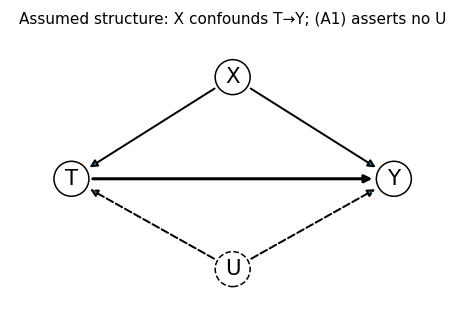

In [6]:
# A minimal directed acyclic graph for the assumed structure.
fig, ax = plt.subplots(figsize=(5.2, 3.2)); ax.axis("off"); ax.grid(False)
pos = {"X": (0.5, 0.9), "T": (0.1, 0.45), "Y": (0.9, 0.45), "U": (0.5, 0.05)}
for k, (x, y) in pos.items():
  ax.text(x, y, k, ha="center", va="center", fontsize=14, bbox=dict(boxstyle="circle,pad=0.35", fc="white", ec="black", ls="--" if k == "U" else "-"))
arrow = dict(arrowstyle="-|>", lw=1.3, shrinkA=14, shrinkB=14)
ax.annotate("", xy=pos["T"], xytext=pos["X"], arrowprops=arrow)
ax.annotate("", xy=pos["Y"], xytext=pos["X"], arrowprops=arrow)
ax.annotate("", xy=pos["Y"], xytext=pos["T"], arrowprops=dict(arrowstyle="-|>", lw=2, shrinkA=14, shrinkB=14))
ax.annotate("", xy=pos["T"], xytext=pos["U"], arrowprops=dict(arrow, ls="--"))
ax.annotate("", xy=pos["Y"], xytext=pos["U"], arrowprops=dict(arrow, ls="--"))
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.1, 1.1)
ax.set_title("Assumed structure: X confounds T→Y; (A1) asserts no U", fontsize=10)
plt.show()

<a id="4"></a>
## 4. The experimental benchmark

### 4.1 Randomization check

Randomization does not guarantee balance in any single sample of 445 men, so I check it. All standardized differences should be small and unsystematic.

In [7]:
balance_table(experiment, COVS).round(3)

,mean_treated,mean_control,SMD,var_ratio
covariate,,,,
age,25.816,25.054,0.107,1.028
education,10.346,10.088,0.141,1.551
black,0.843,0.827,0.044,0.925
hispanic,0.059,0.108,-0.175,0.583
married,0.189,0.154,0.094,1.180
nodegree,0.708,0.835,-0.304,1.500
re74,2095.574,2107.027,-0.002,0.738
re75,1532.055,1266.909,0.084,1.076
u74,0.708,0.750,-0.094,1.104


The imbalances are of the size expected by chance in a sample this small. Nothing here compromises the experiment, but it does mean that a regression-adjusted estimate is a slightly better benchmark than the raw difference in means because it nets out these accidental differences.

### 4.2 Estimators

In a completely randomized experiment $T \perp\!\!\!\perp \{Y(0), Y(1)\}$, so selection bias in (2) is zero and $\tau_{\mathrm{ATT}} = \tau_{\mathrm{ATE}} = \mathbb{E}[Y\mid T=1]-\mathbb{E}[Y\mid T=0]$. I report three estimates:

1. **Difference in means** with the Neyman variance $\;\widehat{V} = s_1^2/N_1 + s_0^2/N_0$.
2. **Regression adjustment** $\;Y = \alpha + \tau T + X'\beta + \varepsilon$ with heteroskedasticity-robust (HC1) standard errors.
3. **Lin's (2013) fully interacted regression** $\;Y = \alpha + \tau T + \tilde X'\beta + T\cdot\tilde X'\gamma + \varepsilon$ with covariates centred at their sample means ($\tilde X = X - \bar X$). Centering makes $\hat\tau$ the estimated ATE even when effects are heterogeneous, and the interacted specification is guaranteed not to hurt precision asymptotically relative to the difference in means.

In [8]:
BASE = ["age", "education", "black", "hispanic", "married", "nodegree", "re74", "re75"]
y1 = experiment.loc[experiment.treat == 1, "re78"]; y0 = experiment.loc[experiment.treat == 0, "re78"]

# 1. Difference in means, Neyman variance
tau_dm = y1.mean() - y0.mean()
se_dm = np.sqrt(y1.var(ddof=1) / len(y1) + y0.var(ddof=1) / len(y0))

# 2. Regression adjustment
Xr = sm.add_constant(experiment[["treat"] + BASE + ["u74", "u75"]])
fit_ra = sm.OLS(experiment["re78"], Xr).fit(cov_type="HC1")

# 3. Lin (2013): centred covariates fully interacted with treatment
Xc = experiment[BASE + ["u74", "u75"]] - experiment[BASE + ["u74", "u75"]].mean()
Xl = pd.concat([experiment[["treat"]], Xc, Xc.mul(experiment["treat"], axis=0).add_suffix("_x_T")], axis=1)
fit_lin = sm.OLS(experiment["re78"], sm.add_constant(Xl)).fit(cov_type="HC1")

benchmark = pd.DataFrame({
    "estimate": [tau_dm, fit_ra.params["treat"], fit_lin.params["treat"]],
    "SE": [se_dm, fit_ra.bse["treat"], fit_lin.bse["treat"]],
}, index=["Difference in means", "Regression adjustment", "Lin (2013) interacted"])
benchmark["95% CI lower"], benchmark["95% CI upper"] = ci(benchmark["estimate"], benchmark["SE"])
BENCH, BENCH_SE = benchmark.loc["Difference in means", ["estimate", "SE"]]
benchmark.round(1)

,estimate,SE,95% CI lower,95% CI upper
Difference in means,1794.3,671.0,479.2,3109.5
Regression adjustment,1670.7,680.2,337.5,3003.9
Lin (2013) interacted,1583.5,666.9,276.3,2890.6


The program raised 1978 earnings of participants by roughly **\$1,800** (about 40% of the control mean of \$4,555), with a standard error of about \$670. Two points about this benchmark are easy to forget and matter for everything below:

- It is itself noisy. Its 95% interval runs from under \$500 to over \$3,100. An observational estimate of \$1,200 is not "wrong" relative to a benchmark of \$1,800; the two differ by less than one standard error of either.
- The 1978 outcome is skewed and heavy-tailed (the treated-group standard deviation of `re78` is about \$7,900 against a mean of \$6,350). Earnings effects are hard to estimate precisely with a few hundred observations no matter how clean the design.

I use the difference in means (\$1,794.34, SE \$671.0) as the reference value, because it involves no modelling choices.

<a id="5"></a>
## 5. Diagnosing the observational comparison

### 5.1 The naive comparison and the measured selection bias

Replacing the experimental controls by CPS-3 and comparing raw means gives the number that a careless analyst would report.

In [11]:
obs_t = observational.treat == 1
naive = observational.loc[obs_t, "re78"].mean() - observational.loc[~obs_t, "re78"].mean()
EY0_T1 = y0.mean() # E[Y(0)|T=1], from the experimental controls
EY0_T0 = observational.loc[~obs_t, "re78"].mean() # E[Y(0)|T=0], the CPS-3 mean
selection_bias = EY0_T1 - EY0_T0

print(f"Naive difference in 1978 earnings (NSW treated - CPS-3): {naive:.2f}")
print(f"E[Y(0)|T=1] from experimental controls: {EY0_T1:.2f}")
print(f"E[Y(0)|T=0] = CPS-3 mean: {EY0_T0:.2f}")
print(f"Selection bias, E[Y(0)|T=1] - E[Y(0)|T=0]: {selection_bias:.2f}")
print(f"Check of decomposition (2): ATT + bias = {BENCH:.2f} + ({selection_bias:.2f}) = {BENCH + selection_bias:.2f}")

Naive difference in 1978 earnings (NSW treated - CPS-3): -635.03
E[Y(0)|T=1] from experimental controls: 4554.80
E[Y(0)|T=0] = CPS-3 mean: 6984.17
Selection bias, E[Y(0)|T=1] - E[Y(0)|T=0]: -2429.37
Check of decomposition (2): ATT + bias = 1794.34 + (-2429.37) = -635.03


The raw comparison says the program *lowered* earnings by \$635. Decomposition (2) shows exactly why: the men who ended up in NSW would have earned about **\$2,429 less** than the CPS-3 men even without the program. The task for every observational estimator is to remove a bias of this magnitude using only the ten covariates in the data.

### 5.2 Covariate imbalance

In [12]:
bal_raw = balance_table(observational, COVS)
bal_raw.round(3)

,mean_treated,mean_control,SMD,var_ratio
covariate,,,,
age,25.816,28.030,-0.242,0.440
education,10.346,10.235,0.045,0.496
black,0.843,0.203,1.668,0.820
hispanic,0.059,0.142,-0.277,0.460
married,0.189,0.513,-0.719,0.616
nodegree,0.708,0.597,0.235,0.862
re74,2095.574,5619.237,-0.596,0.518
re75,1532.055,2466.484,-0.287,0.956
u74,0.708,0.261,0.998,1.075


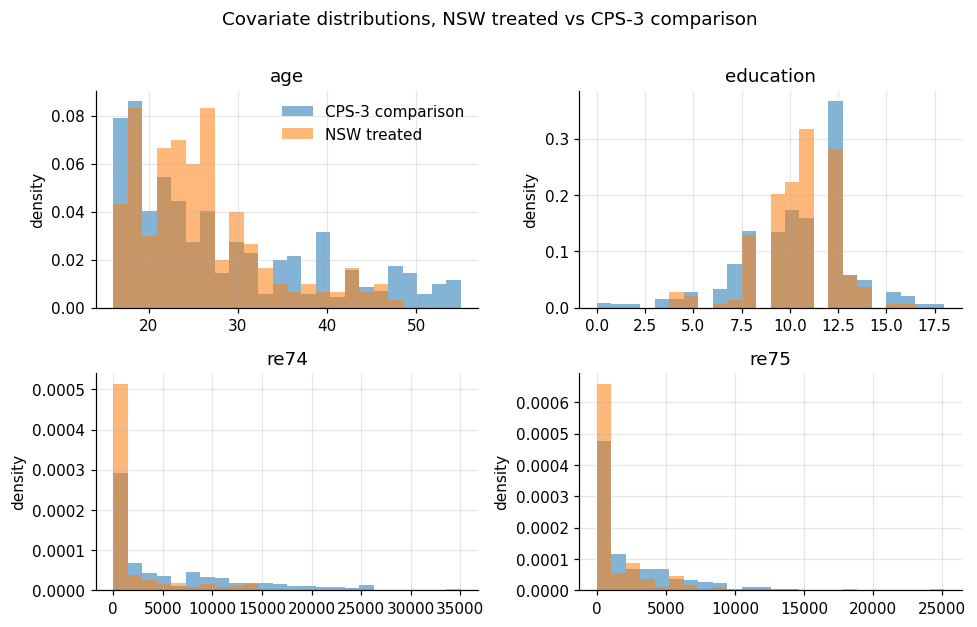

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(9, 5.6))
for ax, col in zip(axes.ravel(), ["age", "education", "re74", "re75"]):
  bins = np.linspace(observational[col].min(), observational[col].max(), 25)
  ax.hist(observational.loc[~obs_t, col], bins=bins, density=True, alpha=0.55, label="CPS-3 comparison")
  ax.hist(observational.loc[obs_t, col], bins=bins, density=True, alpha=0.55, label="NSW treated")
  ax.set_title(col); ax.set_ylabel("density")
axes[0, 0].legend(frameon=False)
plt.suptitle("Covariate distributions, NSW treated vs CPS-3 comparison", y=1.01); plt.tight_layout(); plt.show()

Several covariates are wildly imbalanced: the SMD for `black` is about 1.7 and for `u74` about 1.0—an order of magnitude beyond the 0.1 convention—while `married` and `re74` differ by well over half a standard deviation. The variance ratio for `re74` is about 0.5: the treated distribution of 1974 earnings is a spike at zero, while the CPS-3 distribution is spread out. Any adjustment method has to bridge distributions that barely overlap on several dimensions at once, which is why the choice of method and specification will turn out to matter.

<a id="6"></a>
## 6. Outcome regression and g-computation

### 6.1 Regression with a treatment dummy

The workhorse of applied economics is

$$
Y_i = \alpha + \tau\,T_i + X_i'\beta + \varepsilon_i,
\tag{5}
$$

with $\hat\tau$ read off as "the effect". It is worth being precise about what (5) estimates. If the effect is constant across units and $\mu_0(X)$ is linear in $X$, then (A1) implies $\mathbb{E}[\varepsilon\mid T,X]=0$ and $\hat\tau$ is consistent for the ATT (which equals the ATE). If effects are heterogeneous, the OLS coefficient is a *variance-weighted* average of conditional effects $\tau(X)$—weights proportional to $e(X)(1-e(X))$—that gives the most weight to covariate cells where treatment status is most mixed (Angrist, 1998). Słoczyński (2022) shows that this makes $\hat\tau$ a convex combination of the ATT and the effect on the *untreated*, with weights that are inversely related to group size: with 30% of the sample treated, OLS puts roughly 70% of its weight on the ATT and 30% on an effect for the CPS-3 men—a quantity whose "treated" counterfactual is pure extrapolation. The mixture leans toward the ATT here, but it is not the ATT, and its weights are not something the analyst chooses. I therefore treat (5) as a familiar reference point rather than as the primary estimator.

I estimate (5) for four covariate sets, from the plain linear list to the specification Dehejia and Wahba (1999) used for the CPS samples (age, age², age³, education, education², the demographics, both years of earnings, the zero-earnings indicators, and an education × 1974-earnings interaction). The second set—the linear covariates plus the zero-earnings indicators—is my **primary specification**: it is the most parsimonious set that encodes the eligibility rule, and Section 7 shows it produces the best covariate balance.

In [14]:
observational["age3"] = (observational["age"] / 10) ** 3
SPECS = {
    "linear": BASE,
    "linear + zero-earnings (primary)": BASE + ["u74", "u75"],
    "quadratic + zero-earnings": BASE + ["u74", "u75", "age2", "educ2"],
    "Dehejia-Wahba CPS": BASE + ["u74", "u75", "age2", "age3", "educ2", "educ_re74"],
}
PRIMARY = "linear + zero-earnings (primary)"

def ols_dummy(df, spec):
  X = sm.add_constant(df[["treat"] + spec])
  return sm.OLS(df["re78"], X).fit(cov_type="HC1")

ols_rows = {}
for name, spec in SPECS.items():
  f = ols_dummy(observational, spec)
  ols_rows[name] = {"estimate": f.params["treat"], "SE (HC1)": f.bse["treat"], "t": f.tvalues["treat"], "k": len(spec)}
ols_table = pd.DataFrame(ols_rows).T
ols_table["95% CI lower"], ols_table["95% CI upper"] = ci(ols_table["estimate"], ols_table["SE (HC1)"])
ols_table.round(2)

,estimate,SE (HC1),t,k,95% CI lower,95% CI upper
linear,1548.24,740.58,2.09,8.0,96.74,2999.75
linear + zero-earnings (primary),865.59,738.52,1.17,10.0,-581.88,2313.05
quadratic + zero-earnings,794.45,740.76,1.07,12.0,-657.41,2246.32
Dehejia-Wahba CPS,1075.37,734.20,1.46,14.0,-363.64,2514.39


Conditioning on the covariates flips the sign of the naive comparison and removes most of the 2,429 selection bias: the linear specification gives about 1,550, the primary one about 870. The standard errors (≈ 740) are large enough that none of these is distinguishable from either zero or the benchmark. The drop from 1,550 to 870 when `u74`/`u75` enter is informative: those indicators absorb part of the treated/CPS difference that the linear model had been attributing to the program.

### 6.2 g-computation for the ATT

Equation (3) suggests a cleaner estimator that targets the ATT directly and lets the control regression be estimated only where it is needed:

$$
\hat\tau_{\mathrm{reg}} \;=\; \frac{1}{N_1}\sum_{i:\,T_i=1}\Big(Y_i - \hat\mu_0(X_i)\Big),
\qquad
\hat\mu_0 \text{ fitted by OLS on the comparison units only.}
\tag{6}
$$

Compared with (5), estimator (6) (i) does not impose a constant effect, (ii) uses the control-group regression to *predict* what each trainee would have earned, and (iii) never uses the treated outcomes to estimate $\mu_0$. Its weakness is extrapolation: $\hat\mu_0$ is fitted on the CPS-3 men, and it is evaluated at treated covariate values—young, Black, zero-earnings men—that are rare in that group. A linear extrapolation into a thinly populated region is only as good as the linearity assumption. I obtain standard errors by bootstrapping the whole procedure.

In [15]:
def gcomp_att(df, spec):
  c, t = df[df.treat == 0], df[df.treat == 1]
  mu0 = sm.OLS(c["re78"], sm.add_constant(c[spec])).fit()
  return (t["re78"] - mu0.predict(sm.add_constant(t[spec], has_constant="add"))).mean()

gcomp_rows = {}
for name, spec in SPECS.items():
  est = gcomp_att(observational, spec)
  se, (lo, hi), _ = bootstrap(lambda d, s=spec: gcomp_att(d, s), observational, B=999)
  gcomp_rows[name] = {"estimate": est, "bootstrap SE": se, "pct CI lower": lo, "pct CI upper": hi}
gcomp_table = pd.DataFrame(gcomp_rows).T
gcomp_table.round(1)

,estimate,bootstrap SE,pct CI lower,pct CI upper
linear,1647.6,797.9,95.6,3232.9
linear + zero-earnings (primary),1170.3,812.7,-455.8,2845.6
quadratic + zero-earnings,1313.2,875.7,-350.5,3111.2
Dehejia-Wahba CPS,1842.8,897.3,101.9,3650.8


The ATT-targeted regression estimates are higher than the dummy-variable coefficients. Part of the gap is the estimand: (5) mixes the ATT with an extrapolated effect for the CPS-3 men. Part is the fitting sample: (6) estimates $\hat\mu_0$ from the comparison units alone, whereas (5) forces a common set of slopes on both groups. Bootstrap standard errors are ≈ \$800–\$900 and every interval covers the benchmark.

<a id="7"></a>
## 7. The propensity score: estimation, overlap, balance, weighting

### 7.1 Estimating $e(X)$

I model the propensity score with a logistic regression,

$$
e(X_i;\gamma) = \Lambda(X_i'\gamma) = \frac{1}{1+\exp(-X_i'\gamma)},
$$

estimated by maximum likelihood for each of the four covariate sets. The purpose of this model is *not* prediction of treatment; it is to produce a score that balances the covariates between the treated and the re-weighted comparison group. I therefore judge specifications by balance and by the effective size of the re-weighted comparison group, not by fit statistics. Two overlap diagnostics are reported alongside: the number of CPS-3 men whose estimated score lies below the smallest treated score (they carry almost no weight and matter only for regression extrapolation), and the number of treated men whose score exceeds the largest comparison score (for them, assumption (A2) fails in the sample and the estimators must extrapolate or drop them).

The **ATT weights** implied by (4) are

$$
w_i \;=\; T_i + (1-T_i)\,\frac{\hat e(X_i)}{1-\hat e(X_i)},
\tag{7}
$$

and the **effective sample size** of the weighted comparison group is Kish's $\mathrm{ESS} = (\sum_{i:T_i=0} w_i)^2 / \sum_{i:T_i=0} w_i^2$, which counts how many equally weighted controls the weighted group is worth.

In [16]:
def fit_logit(df, spec):
  X = sm.add_constant(df[spec])
  m = sm.Logit(df["treat"], X).fit(disp=0, maxiter=500)
  return m, np.clip(m.predict(X).values, 1e-6, 1 - 1e-6)

def att_weights(e, t):
  return np.where(t, 1.0, e / (1.0 - e))

def ipw_att(df, e):
  t = (df.treat == 1).values; y = df["re78"].values; w = att_weights(e, t)
  return y[t].mean() - np.average(y[~t], weights=w[~t])

ps = {}; spec_rows = {}
for name, spec in SPECS.items():
  m, e = fit_logit(observational, spec); ps[name] = e
  t = obs_t.values; w = att_weights(e, t)
  b = balance_table(observational, COVS, w=w)
  spec_rows[name] = {
    "k": len(spec), "log-lik": m.llf,
    "ESS of weighted controls": w[~t].sum() ** 2 / (w[~t] ** 2).sum(),
    "max control weight": w[~t].max(),
    "max |SMD| after weighting": b["SMD"].abs().max(),
    "mean |SMD| after weighting": b["SMD"].abs().mean(),
    "controls below min treated e": int((e[~t] < e[t].min()).sum()),
    "treated above max control e": int((e[t] > e[~t].max()).sum()),
    "IPW-ATT": ipw_att(observational, e),
  }
spec_table = pd.DataFrame(spec_rows).T
spec_table.round(3)

,k,log-lik,ESS of weighted controls,max control weight,max |SMD| after weighting,mean |SMD| after weighting,controls below min treated e,treated above max control e,IPW-ATT
linear,8.0,-243.922,99.815,3.743,0.510,0.100,57.0,8.0,1214.071
linear + zero-earnings (primary),10.0,-228.100,71.199,5.849,0.144,0.047,36.0,3.0,1003.387
quadratic + zero-earnings,12.0,-198.289,25.549,23.175,0.170,0.097,116.0,12.0,1350.966
Dehejia-Wahba CPS,14.0,-193.338,19.291,36.738,0.166,0.099,108.0,8.0,1113.626


The table shows the trade-off that governs propensity-score work in small samples. Richer specifications fit the treatment indicator better (the log-likelihood rises by more than 45 points from the linear to the Dehejia–Wahba set) but produce more extreme scores: the effective comparison group shrinks from about 100 men to about 20–25, and the largest single control weight rises from under 4 to between 20 and 40. Balance, the criterion that actually matters, is best for the primary specification, which brings the mean absolute SMD across the ten covariates below 0.05 with an effective comparison group of about 70. The plain linear specification fails to balance the zero-earnings indicators at all (the weighted SMD of `u74` remains about 0.5), which is direct evidence that it misses the selection mechanism. I proceed with the primary specification and report the others as sensitivity checks.

### 7.2 Overlap

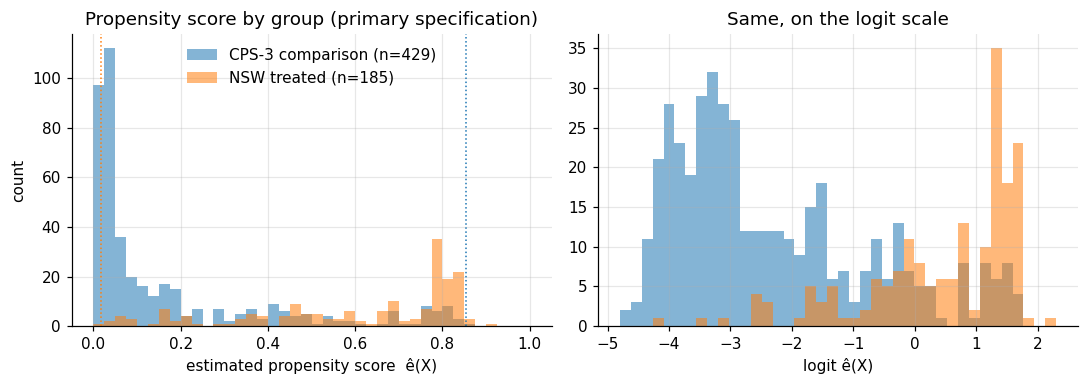

Treated score range   [0.016, 0.909]
Comparison score range[0.0082, 0.854]
Treated units above the largest comparison score: 3
Comparison units below the smallest treated score: 36


In [17]:
e_p = ps[PRIMARY]; t = obs_t.values
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
bins = np.linspace(0, 1, 41)
axes[0].hist(e_p[~t], bins=bins, alpha=0.55, label="CPS-3 comparison (n=429)")
axes[0].hist(e_p[t], bins=bins, alpha=0.55, label="NSW treated (n=185)")
axes[0].axvline(e_p[t].min(), color="C1", ls=":", lw=1); axes[0].axvline(e_p[~t].max(), color="C0", ls=":", lw=1)
axes[0].set_xlabel("estimated propensity score  ê(X)"); axes[0].set_ylabel("count"); axes[0].legend(frameon=False)
axes[0].set_title("Propensity score by group (primary specification)")
lp = np.log(e_p / (1 - e_p)); bins2 = np.linspace(lp.min(), lp.max(), 41)
axes[1].hist(lp[~t], bins=bins2, alpha=0.55); axes[1].hist(lp[t], bins=bins2, alpha=0.55)
axes[1].set_xlabel("logit ê(X)"); axes[1].set_title("Same, on the logit scale")
plt.tight_layout(); plt.show()
print(f"Treated score range   [{e_p[t].min():.3f}, {e_p[t].max():.3f}]")
print(f"Comparison score range[{e_p[~t].min():.4f}, {e_p[~t].max():.3f}]")
print(f"Treated units above the largest comparison score: {(e_p[t] > e_p[~t].max()).sum()}")
print(f"Comparison units below the smallest treated score: {(e_p[~t] < e_p[t].min()).sum()}")

Overlap is adequate but far from comfortable. The comparison group is concentrated at low scores (most CPS-3 men look nothing like trainees), whereas the treated distribution is spread across the whole unit interval, with a mass of men near ê ≈ 0.6–0.85 where only a handful of comparison men live. Those few comparison men will receive large weights (Section 7.4) or be matched many times (Section 8). Three treated men have scores above every comparison score; for them (A2) fails in this sample.

### 7.3 Does the score balance the covariates?

The balancing property is testable: after weighting the comparison group by the odds $\hat e/(1-\hat e)$, its covariate means should match the treated means.

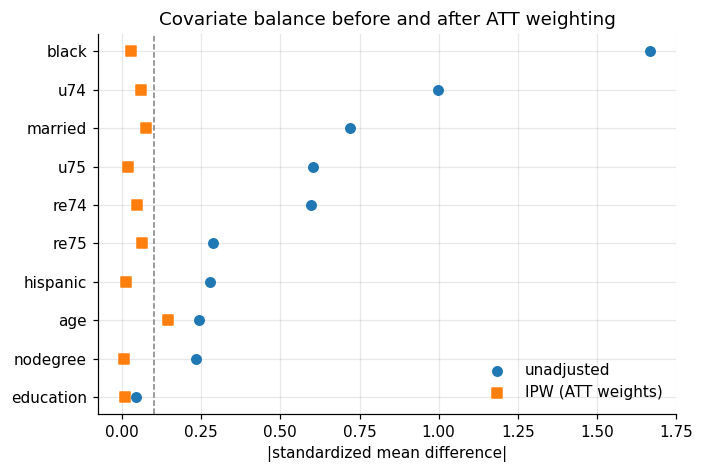

,unadjusted SMD,weighted SMD,unadjusted var ratio
covariate,,,
age,-0.242,0.144,0.440
education,0.045,-0.010,0.496
black,1.668,-0.029,0.820
hispanic,-0.277,0.013,0.460
married,-0.719,0.077,0.616
nodegree,0.235,0.006,0.862
re74,-0.596,0.046,0.518
re75,-0.287,0.064,0.956
u74,0.998,-0.058,1.075


In [20]:
w_p = att_weights(e_p, t)
bal_ipw = balance_table(observational, COVS, w=w_p)
love_plot({"unadjusted": bal_raw["SMD"], "IPW (ATT weights)": bal_ipw["SMD"]}, "Covariate balance before and after ATT weighting")
pd.concat({"unadjusted SMD": bal_raw["SMD"], "weighted SMD": bal_ipw["SMD"], "unadjusted var ratio": bal_raw["var_ratio"]}, axis=1).round(3)

Weighting collapses standardized differences that were as large as 1.7 to below 0.1 for nine of the ten covariates; `age` (0.14) is the only one that remains above the threshold. This is what the balancing property looks like when the model is good enough, and it is the closest thing to a test of the propensity model that the data allow. Nothing here tests (A1): balance on observed covariates says nothing about unobserved ones.

### 7.4 Inverse probability weighting for the ATT

Using the weights (7), the sample analogue of (3)–(4) in its self-normalized (Hájek) form is

$$
\hat\tau_{\mathrm{IPW}} \;=\; \frac{1}{N_1}\sum_{i:\,T_i=1} Y_i \;-\; \frac{\sum_{i:\,T_i=0} w_i Y_i}{\sum_{i:\,T_i=0} w_i}.
\tag{8}
$$

Normalizing by $\sum w_i$ rather than by $N_1$ costs nothing asymptotically and protects against weights that do not sum to what they should in a finite sample. Its variance is estimated by bootstrapping the estimation of $\hat e$ and (8) jointly; because IPW is a smooth functional of the data, the bootstrap is valid here (unlike for matching, Section 8.3).

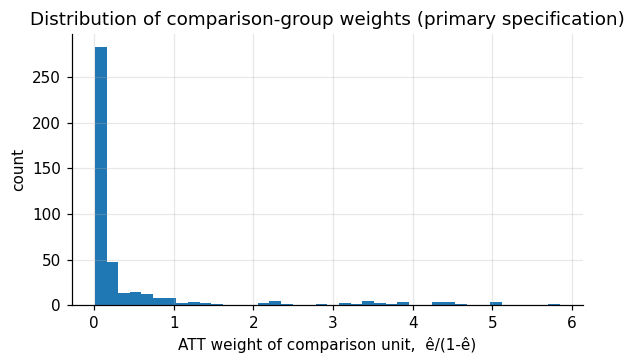

Sum of comparison weights 194.2 | ESS 71.2 of 429 | max weight 5.85 | share of total weight carried by the 10 heaviest units 24.5%


,estimate,bootstrap SE,pct CI lower,pct CI upper
linear,1214.1,784.3,-358.9,2695.6
linear + zero-earnings (primary),1003.4,846.1,-757.7,2619.9
quadratic + zero-earnings,1351.0,1112.7,-935.6,3403.5
Dehejia-Wahba CPS,1113.6,1111.0,-885.9,3266.5


In [21]:
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.hist(w_p[~t], bins=40); ax.set_xlabel("ATT weight of comparison unit,  ê/(1-ê)"); ax.set_ylabel("count")
ax.set_title("Distribution of comparison-group weights (primary specification)"); plt.show()
ess = w_p[~t].sum() ** 2 / (w_p[~t] ** 2).sum()
print(f"Sum of comparison weights {w_p[~t].sum():.1f} | ESS {ess:.1f} of 429 | max weight {w_p[~t].max():.2f} | "
      f"share of total weight carried by the 10 heaviest units {np.sort(w_p[~t])[-10:].sum() / w_p[~t].sum():.1%}")

def ipw_pipeline(df, spec):
  _, e = fit_logit(df, spec)
  return ipw_att(df, e)

ipw_rows = {}
for name, spec in SPECS.items():
  est = ipw_pipeline(observational, spec)
  se, (lo, hi), draws = bootstrap(lambda d, s=spec: ipw_pipeline(d, s), observational, B=999)
  ipw_rows[name] = {"estimate": est, "bootstrap SE": se, "pct CI lower": lo, "pct CI upper": hi}
ipw_table = pd.DataFrame(ipw_rows).T
ipw_table.round(1)

The primary IPW estimate is about **\$1,000** with a bootstrap standard error of roughly *\$850*. The weight diagnostics explain the standard error: the ten heaviest comparison men carry about a quarter of the total weight, and the estimator is effectively comparing 185 trainees with 71 "equivalent" controls. Across specifications the IPW-ATT ranges from about *\$1,000* to *\$1,350*, and the richer specifications pay for their extra flexibility with standard errors above *\$1,100*.

### 7.5 Why ATE weights give the wrong answer here

The estimator most often labelled "IPTW" in textbooks uses the ATE weights $1/\hat e$ for treated and $1/(1-\hat e)$ for comparison units. Applied to this sample it produces something that looks like a failure of weighting.

In [22]:
def ipw_ate(df, e):
  t = (df.treat == 1).values; y = df["re78"].values
  w = np.where(t, 1 / e, 1 / (1 - e))
  return np.average(y[t], weights=w[t]) - np.average(y[~t], weights=w[~t])

for name in ["linear", PRIMARY]:
  e = ps[name]
  print(f"{name:34s} IPW with ATE weights: {ipw_ate(observational, e):8.1f}   |  with ATT weights: {ipw_att(observational, e):8.1f}"
        f"   | largest treated ATE weight 1/ê = {1 / e[t].min():.1f}")

linear                             IPW with ATE weights:    224.7   |  with ATT weights:   1214.1   | largest treated ATE weight 1/ê = 40.1
linear + zero-earnings (primary)   IPW with ATE weights:   -412.9   |  with ATT weights:   1003.4   | largest treated ATE weight 1/ê = 61.5


With the linear specification the ATE-weighted estimate is \$225, more than five times smaller than the ATT estimate from the *same* propensity model, and with the primary specification it is negative. Nothing about the weighting machinery has failed. The ATE weights re-weight both groups toward the pooled population, which is 70% CPS-3. Trainees who look most unlike the CPS men—those with the lowest scores—are inflated by factors of up to 1/ê ≈ 40–60 to stand in for the (largely absent) CPS-type trainees, and the resulting number is an estimate of what the programme would do to the average CPS-3 man. That quantity is not what the experiment measures and has no policy relevance. When a benchmark comparison shows weighting "failing", the first thing to check is the estimand.

### 7.6 Sensitivity to overlap trimming

Dehejia and Wahba discard comparison units whose score is below the smallest treated score. Under ATT weighting such units already receive negligible weight, but they do influence regression-based estimators because they help pin down $\hat\mu_0$ in a region where no trainee lives. I re-estimate the primary specification on the trimmed sample.

In [23]:
spec_p = SPECS[PRIMARY]
keep = t | (e_p >= e_p[t].min())
trimmed = observational[keep].reset_index(drop=True)
_, e_tr = fit_logit(trimmed, spec_p)
print(f"Trimmed sample: {keep.sum()} units ({(~keep).sum()} comparison men dropped)")
print(f"OLS dummy      full {ols_dummy(observational, spec_p).params['treat']:8.1f}   trimmed {ols_dummy(trimmed, spec_p).params['treat']:8.1f}")
print(f"g-computation  full {gcomp_att(observational, spec_p):8.1f}   trimmed {gcomp_att(trimmed, spec_p):8.1f}")
print(f"IPW-ATT        full {ipw_att(observational, e_p):8.1f}   trimmed {ipw_att(trimmed, e_tr):8.1f}")

Trimmed sample: 578 units (36 comparison men dropped)
OLS dummy      full    865.6   trimmed    882.4
g-computation  full   1170.3   trimmed   1180.1
IPW-ATT        full   1003.4   trimmed   1016.4


Trimming changes every estimate by less than \$20, so the primary results are not driven by CPS-3 men far outside the trainee region.

<a id="8"></a>
## 8. Matching

### 8.1 Nearest-neighbour matching on the propensity score

Matching estimates $\mathbb{E}[\mu_0(X)\mid T=1]$ in (3) nonparametrically: for each treated man, find the comparison man (or the $M$ comparison men) closest to him and use their outcomes as the counterfactual. I match on the *logit* of the estimated score, $\hat\ell_i = \log\{\hat e_i/(1-\hat e_i)\}$, which spreads out the extremes where the score itself is compressed, and I match **with replacement** so that every treated man gets his best available match even when comparison men are scarce in his region. Let $\mathcal{J}_M(i)$ be the set of the $M$ nearest comparison units to treated unit $i$ and let

$$
K_M(j) \;=\; \sum_{i:\,T_i=1}\frac{\mathbb{1}\{j\in\mathcal{J}_M(i)\}}{M}
$$

count (fractionally) how many times comparison unit $j$ is used. The matching estimator of the ATT is

$$
\hat\tau_{M} \;=\; \frac{1}{N_1}\sum_{i:\,T_i=1}\Big(Y_i - \frac{1}{M}\sum_{j\in\mathcal{J}_M(i)} Y_j\Big)
\;=\; \frac{1}{N_1}\Big(\sum_{i:\,T_i=1} Y_i \;-\; \sum_{j:\,T_j=0} K_M(j)\,Y_j\Big).
\tag{9}
$$

The second form makes clear that matching with replacement *is* a weighting estimator whose comparison-group weights are the integer-valued $K_M(j)$; a comparison man used ten times has ten times the influence of one used once. For the one-to-one case I also impose a caliper of $0.2$ standard deviations of $\hat\ell$ (Austin, 2011): a treated unit whose nearest comparison unit lies farther than that is dropped rather than matched to someone dissimilar.

### 8.2 Valid standard errors: the Abadie–Imbens variance

Conditional on the covariates and treatment assignments, (9) is a linear combination of outcomes, so its variance is

$$
\mathbb{V}\big(\hat\tau_M\mid X,T\big) \;=\; \frac{1}{N_1^2}\Big(\sum_{i:\,T_i=1}\sigma^2_1(X_i) \;+\; \sum_{j:\,T_j=0} K_M(j)^2\,\sigma^2_0(X_j)\Big),
\tag{10}
$$

where $\sigma^2_w(x) = \mathbb{V}(Y\mid X=x, T=w)$. Abadie and Imbens (2006) estimate $\sigma^2_w(X_i)$ locally, by matching unit $i$ to its $J$ nearest neighbours *within its own treatment group* and using the squared deviation from their mean, $\hat\sigma^2_w(X_i) = \tfrac{J}{J+1}\big(Y_i - \tfrac1J\sum_{l\in\mathcal{L}_J(i)}Y_l\big)^2$; I use $J=2$. The $K_M(j)^2$ term is the whole story of why one-to-one matching can be so imprecise: reusing a comparison unit $K$ times contributes $K^2$, not $K$, to the variance. Formula (10) treats the estimand as the ATT *for this sample of trainees*; the variance of the population ATT adds a term for heterogeneity of $\tau(X)$ across treated men, and matching on an *estimated* score adds a further correction (Abadie and Imbens, 2016) that I do not attempt here.

Abadie and Imbens (2008) proved that the ordinary bootstrap is inconsistent for nearest-neighbour matching estimators: resampling changes how often each comparison unit is matched in a way that does not mimic the sampling distribution of $K_M(j)$. The common shortcut of bootstrapping the *fixed* matched sample is worse still, because it treats the matches as data rather than as estimated objects. I compute it below only to show how far off it is.

In [25]:
def nn_match_att(lp, t, y, M=1, caliper_sd=None, J=2):
  # Nearest-neighbour matching on lp (logit score) with replacement; ATT with Abadie-Imbens (2006) variance.
  lt, lc = lp[t].reshape(-1, 1), lp[~t].reshape(-1, 1)
  yt, yc = y[t], y[~t]
  d, idx = NearestNeighbors(n_neighbors=M).fit(lc).kneighbors(lt)
  keep = np.ones(len(lt), bool)
  if caliper_sd is not None:
    keep = d[:, 0] <= caliper_sd * lp.std(ddof=1)
  idx = idx[keep]; n1 = keep.sum()
  K = np.bincount(idx.ravel(), minlength=len(lc)) / M
  tau = (yt[keep] - yc[idx].mean(axis=1)).mean()
  def sigma2(l, yy):
    _, ii = NearestNeighbors(n_neighbors=J + 1).fit(l).kneighbors(l)
    return (J / (J + 1)) * (yy - yy[ii[:, 1:]].mean(axis=1)) ** 2
  V = (sigma2(lt, yt)[keep].sum() + (K ** 2 * sigma2(lc, yc)).sum()) / n1 ** 2
  return {"estimate": tau, "AI SE": np.sqrt(V), "n treated used": int(n1), "distinct controls": int((K > 0).sum()),
          "max K": K.max(), "sum K^2": (K ** 2).sum(), "K": K, "idx": idx, "keep": keep}

y_obs = observational["re78"].values
match_rows = {}
for name in SPECS:
  lp = np.log(ps[name] / (1 - ps[name]))
  r = nn_match_att(lp, t, y_obs, M=1, caliper_sd=0.2)
  match_rows[name] = {k: v for k, v in r.items() if k not in ("K", "idx", "keep")}
match1_table = pd.DataFrame(match_rows).T
match1_table.round(2)

,estimate,AI SE,n treated used,distinct controls,max K,sum K^2
linear,1751.87,1041.30,184.0,80.0,12.0,770.0
linear + zero-earnings (primary),-1682.46,1563.95,184.0,73.0,19.0,1096.0
quadratic + zero-earnings,418.21,1080.05,184.0,63.0,17.0,1286.0
Dehejia-Wahba CPS,-594.77,1365.46,185.0,63.0,25.0,1573.0


One-to-one matching is not a stable estimator in this sample. The primary specification, which balances the covariates best under weighting, yields the most negative number. The columns to the right explain why. Only 60–80 distinct comparison men are ever used, a single man is used up to 25 times, and $\sum_j K(j)^2$ runs from about 760 to nearly 1,600 where an ideal matched design would have 185. The Abadie–Imbens standard errors, \$1,000–\$1,560, reflect this and are far larger than those of the weighting and regression estimators.

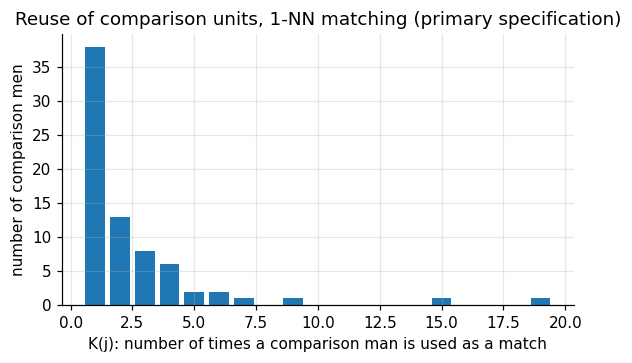

Most heavily reused comparison men:
        K     ps  age  education  black  married  re74    re75      re78
387  19.0  0.833   19         11      1        0   0.0   0.000  16485.52
385  15.0  0.775   20         12      1        0   0.0   0.000  11594.24
380   9.0  0.797   21         13      1        0   0.0   0.000  17941.08
290   7.0  0.674   16          6      1        0   0.0  44.758      0.00
379   6.0  0.602   34         12      1        1   0.0   0.000  18716.88

Contribution of these five men to the matched-control mean: $4,135


In [26]:
lp_p = np.log(e_p / (1 - e_p))
r1 = nn_match_att(lp_p, t, y_obs, M=1, caliper_sd=0.2)
K = r1["K"]
ctrl = observational[~t].reset_index(drop=True).assign(K=K, ps=e_p[~t])
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.bar(*np.unique(K[K > 0], return_counts=True))
ax.set_xlabel("K(j): number of times a comparison man is used as a match"); ax.set_ylabel("number of comparison men")
ax.set_title("Reuse of comparison units, 1-NN matching (primary specification)"); plt.show()
print("Most heavily reused comparison men:")
print(ctrl.sort_values("K", ascending=False).head(5)[["K", "ps", "age", "education", "black", "married", "re74", "re75", "re78"]].round(3).to_string())
share = (ctrl.sort_values("K", ascending=False).head(5).eval("K * re78").sum() / r1["n treated used"])
print(f"\nContribution of these five men to the matched-control mean: ${share:,.0f}")

The problem is concrete. The comparison man with the highest score has the covariates of a typical trainee—young, Black, no earnings in either pre-period—so he is the nearest neighbour of nineteen treated men, and he happens to have earned \$16,486 in 1978. He alone adds about \$1,700 to the matched counterfactual mean of roughly \$8,000, and the five most-used men together account for more than half of it. Under the linear specification a different man, with earnings of \$34, is the one reused a dozen times, and the estimate lands \$3,800 higher. Matching with $M=1$ in a comparison pool where the relevant region contains a few dozen men is a lottery over which of those men gets reused.

In [27]:
# The invalid bootstrap on the fixed matched sample (for illustration only).
matched_y = np.concatenate([y_obs[t][r1["keep"]], y_obs[~t][r1["idx"].ravel()]])
matched_t = np.r_[np.ones(r1["n treated used"]), np.zeros(r1["n treated used"])]
draws = []
rb = np.random.default_rng(SEED)
for _ in range(999):
  ii = rb.integers(0, len(matched_y), len(matched_y))
  draws.append(matched_y[ii][matched_t[ii] == 1].mean() - matched_y[ii][matched_t[ii] == 0].mean())
print(f"Abadie-Imbens SE (valid):                        {r1['AI SE']:8.1f}")
print(f"Bootstrap of the fixed matched sample (invalid): {np.std(draws, ddof=1):8.1f}")

Abadie-Imbens SE (valid):                          1563.9
Bootstrap of the fixed matched sample (invalid):    786.7


The naive bootstrap understates the standard error by about half, because it treats the nineteen copies of the same man as nineteen independent observations. Reported with that standard error, a matching estimate of −\$1,700 would look like evidence that the program hurt trainees; with the correct one it is simply uninformative.

### 8.3 Trading bias for variance: $M$ matches and bias correction

Using $M>1$ matches shrinks the $K_M(j)^2$ term at the cost of pulling in comparison men who are less similar—the classic bias–variance trade-off. Abadie and Imbens (2011) show that the bias from imperfect matches can be estimated and removed: fit $\hat\mu_0(x)$ on the matched comparison units and adjust each pair by the predicted difference,

$$
\hat\tau_{M}^{\mathrm{bc}} \;=\; \frac{1}{N_1}\sum_{i:\,T_i=1}\Big[\big(Y_i - \tfrac1M\textstyle\sum_{j\in\mathcal{J}_M(i)} Y_j\big) - \big(\hat\mu_0(X_i) - \tfrac1M\textstyle\sum_{j\in\mathcal{J}_M(i)}\hat\mu_0(X_j)\big)\Big].
\tag{11}
$$

I sweep $M$ from 1 to 20 for the primary specification, reporting the raw and bias-corrected estimates, the Abadie–Imbens standard error, and the balance of the matched comparison group (weighted by $K_M$).

In [28]:
def bias_corrected(lp, t, y, X, M):
  r = nn_match_att(lp, t, y, M=M)
  K, idx, keep = r["K"], r["idx"], r["keep"]
  Xc, Xt = X[~t], X[t][keep]; yc, yt = y[~t], y[t][keep]
  used = K > 0
  mu0 = sm.WLS(yc[used], sm.add_constant(Xc[used]), weights=K[used]).fit()
  m_t = mu0.predict(sm.add_constant(Xt, has_constant="add")); m_c = mu0.predict(sm.add_constant(Xc, has_constant="add"))
  return ((yt - yc[idx].mean(axis=1)) - (m_t - m_c[idx].mean(axis=1))).mean()

X_p = observational[spec_p].values
sweep = {}
for M in [1, 2, 3, 5, 10, 20]:
  r = nn_match_att(lp_p, t, y_obs, M=M)
  w_m = np.zeros(len(t)); w_m[t] = 1.0; w_m[~t] = r["K"]
  b = balance_table(observational, COVS, w=w_m)
  sweep[M] = {"estimate": r["estimate"], "bias-corrected": bias_corrected(lp_p, t, y_obs, X_p, M), "AI SE": r["AI SE"],
              "distinct controls": r["distinct controls"], "max K": r["max K"],
              "max |SMD|": b["SMD"].abs().max(), "mean |SMD|": b["SMD"].abs().mean()}
sweep_table = pd.DataFrame(sweep).T; sweep_table.index.name = "M"
sweep_table.round({"estimate": 1, "bias-corrected": 1, "AI SE": 1, "distinct controls": 0, "max K": 2, "max |SMD|": 3, "mean |SMD|": 3})

,estimate,bias-corrected,AI SE,distinct controls,max K,max |SMD|,mean |SMD|
M,,,,,,,
1,-1669.1,-1328.9,1557.4,73.0,19.00,0.245,0.061
2,-551.6,-336.4,1264.8,110.0,11.50,0.207,0.059
3,-70.2,121.2,1151.6,132.0,8.67,0.158,0.051
5,632.9,580.5,980.8,160.0,6.20,0.080,0.031
10,1056.6,1047.5,842.9,207.0,5.50,0.097,0.031
20,1146.8,1116.6,849.7,246.0,5.10,0.117,0.044


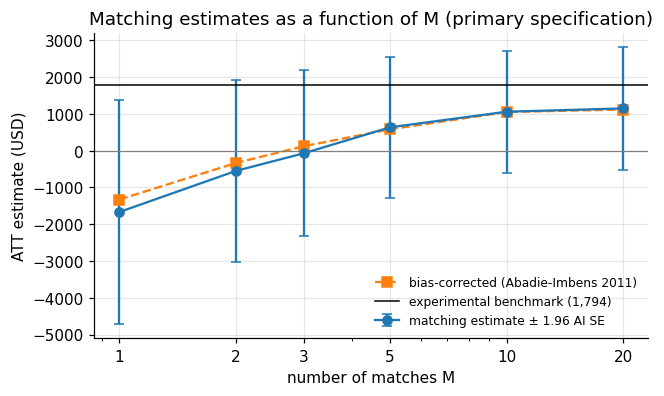

In [29]:
fig, ax = plt.subplots(figsize=(6.5, 3.6))
Ms = sweep_table.index.values
ax.errorbar(Ms, sweep_table["estimate"], yerr=1.96 * sweep_table["AI SE"], fmt="o-", capsize=3, label="matching estimate ± 1.96 AI SE")
ax.plot(Ms, sweep_table["bias-corrected"], "s--", label="bias-corrected (Abadie-Imbens 2011)")
ax.axhline(BENCH, color="k", lw=1, label=f"experimental benchmark ({BENCH:,.0f})"); ax.axhline(0, color="grey", lw=0.8)
ax.set_xscale("log"); ax.set_xticks(Ms); ax.set_xticklabels(Ms); ax.set_xlabel("number of matches M"); ax.set_ylabel("ATT estimate (USD)")
ax.legend(frameon=False, fontsize=8); ax.set_title("Matching estimates as a function of M (primary specification)"); plt.show()

As $M$ grows the estimate climbs from −\$1,700 to about **\$1,050–\$1,150** and the standard error falls from *\$1,560* to about \$850, while balance actually *improves* up to $M\approx 10$ (mean $|\mathrm{SMD}|$ ≈ 0.03) because the influence of any single comparison man is diluted. Bias correction moves the estimates only modestly, which says that the matches are not systematically far from their treated units on the covariates; the instability at low $M$ is variance, not bias. A rule of choosing the smallest $M$ that keeps every $|\mathrm{SMD}|$ below 0.1 while minimizing the estimated variance selects $M=10$; I carry that estimate (labelled "matching, M = 10") into the synthesis, and I note that the rule was applied after seeing the sweep. The larger message is that with 429 comparison men, one-to-one matching should not be the estimator of choice: it discards most of the comparison group and hands the result to a few individuals.

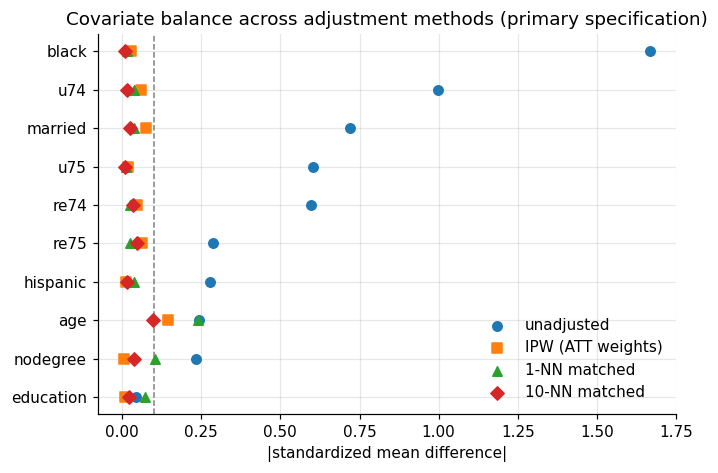

In [30]:
r10 = nn_match_att(lp_p, t, y_obs, M=10)
w_m10 = np.zeros(len(t)); w_m10[t] = 1.0; w_m10[~t] = r10["K"]
w_m1 = np.zeros(len(t)); w_m1[t] = r1["keep"].astype(float); w_m1[~t] = r1["K"]
love_plot({"unadjusted": bal_raw["SMD"], "IPW (ATT weights)": bal_ipw["SMD"],
           "1-NN matched": balance_table(observational, COVS, w=w_m1)["SMD"],
           "10-NN matched": balance_table(observational, COVS, w=w_m10)["SMD"]},
          "Covariate balance across adjustment methods (primary specification)")

<a id="9"></a>
## 9. Doubly robust estimation

### 9.1 Augmented inverse probability weighting

Regression (Section 6) is consistent if $\mu_0(X)$ is correctly specified; weighting (Section 7) is consistent if $e(X)$ is. Neither model is known to be right. The augmented IPW (AIPW) estimator of Robins, Rotnitzky and Zhao (1994) combines them so that consistency requires only one of the two to be correct:

$$
\hat\tau_{\mathrm{AIPW}} \;=\; \frac{1}{N_1}\sum_{i:\,T_i=1}\big(Y_i - \hat\mu_0(X_i)\big)
\;-\; \frac{\sum_{i:\,T_i=0} \hat w_i\,\big(Y_i - \hat\mu_0(X_i)\big)}{\sum_{i:\,T_i=0}\hat w_i},
\qquad \hat w_i = \frac{\hat e(X_i)}{1-\hat e(X_i)}.
\tag{12}
$$

The first term is the g-computation estimator (6). The second re-weights the *residuals* of the control regression rather than the outcomes. Why this delivers double robustness is visible from the population version, writing $r(X) = Y - \mu_0^*(X)$ for the residual from a possibly misspecified $\mu_0^*$:

- If $\mu_0^* = \mu_0$, then $\mathbb{E}[r(X)\mid X, T=0] = 0$, so the second term has expectation zero *whatever* the weights are, and (12) reduces to the g-formula (3).
- If $e^* = e$, then by the weighting identity (4) the second term equals $\mathbb{E}[r(X)\mid T=1] = \mathbb{E}[Y(0)\mid T=1] - \mathbb{E}[\mu_0^*(X)\mid T=1]$, which cancels the misspecification error carried by the first term.

Write $a = \mathbb{E}[Y-\mu_0(X)\mid T=1]$ for the first term of (12) and $b$ for the second (the odds-weighted mean of the control residuals), so that $\tau_{\mathrm{ATT}} = a-b$. Treating the nuisance functions as known, the influence function of the Hájek-normalized estimator is

$$
\varphi_i \;=\; \frac{1}{p}\Big[T_i\big(Y_i - \mu_0(X_i) - a\big) - (1-T_i)\,\frac{e(X_i)}{1-e(X_i)}\big(Y_i - \mu_0(X_i) - b\big)\Big],
\qquad p=\Pr(T=1),
\tag{13}
$$

so that $\widehat{\mathrm{SE}} = \big(\sum_i \hat\varphi_i^2\big)^{1/2}/N$. When $\mu_0$ is correctly specified, $a=\tau_{\mathrm{ATT}}$ and $b=0$ and (13) reduces to the familiar efficient influence function. The standard error based on (13) ignores the first-order effect of estimating the nuisance functions, which is legitimate when both are correctly specified (the estimator is Neyman-orthogonal in the nuisances) but not in general; I therefore report the bootstrap alongside it.

In [31]:
def aipw_att(df, spec_ps, spec_out, e=None):
  t_ = (df.treat == 1).values; y = df["re78"].values
  if e is None:
    _, e = fit_logit(df, spec_ps)
  c = df[~t_]
  mu0 = sm.OLS(c["re78"], sm.add_constant(c[spec_out])).fit().predict(sm.add_constant(df[spec_out], has_constant="add")).values
  w = e / (1 - e)
  a = (y[t_] - mu0[t_]).mean()
  b = np.sum(w[~t_] * (y[~t_] - mu0[~t_])) / np.sum(w[~t_])
  tau = a - b
  phi = (t_ * (y - mu0 - a) - (1 - t_) * w * (y - mu0 - b)) / t_.mean()
  return tau, np.sqrt(np.sum(phi ** 2)) / len(y)

aipw_rows = {}
for name, spec in SPECS.items():
  est, se_if = aipw_att(observational, spec, spec)
  se_b, (lo, hi), _ = bootstrap(lambda d, s=spec: aipw_att(d, s, s)[0], observational, B=999)
  aipw_rows[name] = {"estimate": est, "IF SE": se_if, "bootstrap SE": se_b, "pct CI lower": lo, "pct CI upper": hi}
aipw_table = pd.DataFrame(aipw_rows).T
aipw_table.round(1)

,estimate,IF SE,bootstrap SE,pct CI lower,pct CI upper
linear,1231.0,810.5,787.9,-357.8,2744.4
linear + zero-earnings (primary),851.8,876.4,837.3,-861.0,2414.6
quadratic + zero-earnings,906.6,1071.1,1026.6,-1059.1,2777.7
Dehejia-Wahba CPS,709.2,1216.7,1160.2,-1443.0,2937.8


The doubly robust estimate under the primary specification is about **\$850** (IF standard error ≈ \$880, bootstrap ≈ \$840; the agreement between the two is reassuring). It sits a little below the IPW and g-computation estimates that it combines. Across specifications the AIPW estimates range from about *\$710* to \$1,230, and the standard errors rise steeply for the richer propensity models: double robustness protects against bias from misspecifying one of the two nuisance models, not against the variance that extreme odds weights generate. In this sample the binding constraint is variance, not model form.

### 9.2 Cross-fitted AIPW with flexible nuisance functions

The parametric models above are theory-driven but rigid. Chernozhukov et al. (2018) show that the AIPW moment condition (12)–(13) tolerates machine-learning estimates of $e(X)$ and $\mu_0(X)$ provided they are learned on data not used for evaluating the moment ("cross-fitting"), which removes the over-fitting bias that plagues plug-in estimators. I implement $K=5$-fold cross-fitting with random forests for both nuisances, repeat the random split $S=10$ times, and aggregate as they recommend—the point estimate is the median over splits and the variance adds the dispersion across splits,

$$
\hat\tau = \operatorname{median}_s \hat\tau^{(s)},\qquad
\widehat{\mathrm{SE}}^2 = \operatorname{median}_s\Big(\widehat{\mathrm{SE}}^{(s)2} + \big(\hat\tau^{(s)}-\hat\tau\big)^2\Big).
$$

With 614 observations and 185 treated men this is an exercise in humility rather than a recommended primary estimator: the forests must be kept smooth (I vary the minimum leaf size) and the scores are clipped to $[0.01, 0.95]$ to keep the odds weights bounded.

In [32]:
def crossfit_aipw(df, feats, seed, K=5, min_leaf=20, n_trees=200, clip=(0.01, 0.95)):
  X = df[feats].values; y = df["re78"].values; T = (df.treat == 1).values.astype(int)
  e_hat = np.zeros(len(y)); mu0 = np.zeros(len(y))
  for tr, te in KFold(K, shuffle=True, random_state=seed).split(X):
    clf = RandomForestClassifier(n_estimators=n_trees, min_samples_leaf=min_leaf, random_state=seed, n_jobs=-1).fit(X[tr], T[tr])
    e_hat[te] = clf.predict_proba(X[te])[:, 1]
    ctr = tr[T[tr] == 0]
    reg = RandomForestRegressor(n_estimators=n_trees, min_samples_leaf=min_leaf, random_state=seed, n_jobs=-1).fit(X[ctr], y[ctr])
    mu0[te] = reg.predict(X[te])
  e_hat = np.clip(e_hat, *clip); t_ = T == 1; w = e_hat / (1 - e_hat)
  a = (y[t_] - mu0[t_]).mean()
  b = np.sum(w[~t_] * (y[~t_] - mu0[~t_])) / np.sum(w[~t_])
  tau = a - b
  phi = (t_ * (y - mu0 - a) - (1 - t_) * w * (y - mu0 - b)) / t_.mean()
  return tau, np.sqrt(np.sum(phi ** 2)) / len(y)

dml_rows = {}
for leaf in [10, 20, 40]:
  res = np.array([crossfit_aipw(observational, spec_p, seed=SEED + s, min_leaf=leaf) for s in range(10)])
  med = np.median(res[:, 0]); se = np.sqrt(np.median(res[:, 1] ** 2 + (res[:, 0] - med) ** 2))
  dml_rows[f"min_samples_leaf = {leaf}"] = {"median estimate": med, "SE (DML aggregation)": se,
                                            "min over splits": res[:, 0].min(), "max over splits": res[:, 0].max()}
dml_table = pd.DataFrame(dml_rows).T
DML_EST, DML_SE = dml_table.loc["min_samples_leaf = 20", ["median estimate", "SE (DML aggregation)"]]
dml_table.round(1)

,median estimate,SE (DML aggregation),min over splits,max over splits
min_samples_leaf = 10,654.0,792.6,334.3,927.1
min_samples_leaf = 20,995.8,741.2,854.9,1154.5
min_samples_leaf = 40,1162.7,702.2,1087.1,1333.4


With moderately smooth forests the cross-fitted estimate is close to the parametric AIPW and IPW estimates (about \$1,000 with a standard error near \$750), and it drifts upward as the forests are made smoother. The dispersion across random splits—several hundred dollars at the smallest leaf size—is a reminder that in a sample this small the sample-splitting itself is a material source of noise. I carry the `min_samples_leaf = 20` result into the synthesis as a robustness check rather than as a headline number.

<a id="10"></a>
## 10. Sensitivity to unobserved confounding

Balance on observed covariates does nothing to justify (A1). The experimental benchmark provides one kind of check: if the adjusted estimates fall short of \$1,794, unobserved selection is a candidate explanation, though so is sampling error. A formal sensitivity analysis asks a different and more portable question: how strong would an unobserved confounder have to be to change the conclusion? I use two tools that are common in the current literature.

### 10.1 Omitted-variable bias in $R^2$ units: robustness values (Cinelli and Hazlett, 2020)

For the regression (5), let $Z$ be an omitted confounder and define two partial $R^2$ values: $R^2_{Y\sim Z\mid T,X}$, the share of the residual variance of $Y$ that $Z$ would explain, and $R^2_{T\sim Z\mid X}$, the share of the residual variance of $T$. Cinelli and Hazlett show that the bias of $\hat\tau$ is bounded by

$$
|\mathrm{bias}| \;=\; \widehat{\mathrm{SE}}(\hat\tau)\,\sqrt{\mathrm{df}}\;\sqrt{\frac{R^2_{Y\sim Z\mid T,X}\;R^2_{T\sim Z\mid X}}{1-R^2_{T\sim Z\mid X}}},
\tag{14}
$$

with $\mathrm{df}$ the residual degrees of freedom. The **robustness value** $RV_q$ is the common strength $R^2_{Y\sim Z\mid T,X} = R^2_{T\sim Z\mid X} = RV_q$ at which the bias equals a fraction $q$ of the estimate; with $f_q = q\,|t_{\hat\tau}|/\sqrt{\mathrm{df}}$,

$$
RV_q \;=\; \tfrac12\Big(\sqrt{f_q^4 + 4f_q^2} - f_q^2\Big),
\qquad
RV_{q,\alpha}\text{ replaces } f_q \text{ by } f_q - t_{\alpha/2,\mathrm{df}-1}/\sqrt{\mathrm{df}-1}
$$

for the strength needed to make the estimate statistically insignificant at level $\alpha$. The partial $R^2$ of the treatment itself, $R^2_{Y\sim T\mid X} = t_{\hat\tau}^2/(t_{\hat\tau}^2+\mathrm{df})$, gives the extreme case of a confounder that explains *all* the residual outcome variance. To calibrate what "strong" means I benchmark against the observed covariates: the partial $R^2$ of `re74` and `re75` with the outcome, and of `black` and `u74` with treatment, are the natural yardsticks in this application.

In [33]:
fit_p = sm.OLS(observational["re78"], sm.add_constant(observational[["treat"] + spec_p])).fit()
fit_t = sm.OLS(observational["treat"], sm.add_constant(observational[spec_p])).fit()
t_stat, df_res = fit_p.tvalues["treat"], fit_p.df_resid

def partial_r2(tval, dof):
  return tval ** 2 / (tval ** 2 + dof)

def robustness_value(tval, dof, q=1.0, alpha=None):
  f = q * abs(tval) / np.sqrt(dof)
  if alpha is not None:
    f = f - stats.t.ppf(1 - alpha / 2, dof - 1) / np.sqrt(dof - 1)
    if f < 0: return 0.0
  return 0.5 * (np.sqrt(f ** 4 + 4 * f ** 2) - f ** 2)

print(f"OLS (primary): tau = {fit_p.params['treat']:.1f}, t = {t_stat:.2f}, df = {int(df_res)}")
print(f"Partial R2 of treatment with outcome, R2_Y~T|X : {partial_r2(t_stat, df_res):.4f}")
print(f"Robustness value RV_1 (bias = 100% of estimate) : {robustness_value(t_stat, df_res):.4f}")
print(f"Robustness value RV_1,0.05 (to lose significance): {robustness_value(t_stat, df_res, alpha=0.05):.4f}")
bench_r2 = pd.DataFrame({"R2_Y~Z|T,X": {v: partial_r2(fit_p.tvalues[v], df_res) for v in spec_p},
                         "R2_T~Z|X": {v: partial_r2(fit_t.tvalues[v], fit_t.df_resid) for v in spec_p}})
print("\nBenchmark partial R2 of observed covariates:")
print(bench_r2.to_string(float_format=lambda x: f"{x:.4f}"))

OLS (primary): tau = 865.6, t = 1.08, df = 602
Partial R2 of treatment with outcome, R2_Y~T|X : 0.0019
Robustness value RV_1 (bias = 100% of estimate) : 0.0431
Robustness value RV_1,0.05 (to lose significance): 0.0000

Benchmark partial R2 of observed covariates:
           R2_Y~Z|T,X  R2_T~Z|X
age            0.0000    0.0001
education      0.0080    0.0051
black          0.0060    0.2441
hispanic       0.0004    0.0045
married        0.0007    0.0095
nodegree       0.0000    0.0044
re74           0.0573    0.0005
re75           0.0118    0.0061
u74            0.0156    0.0470
u75            0.0003    0.0018


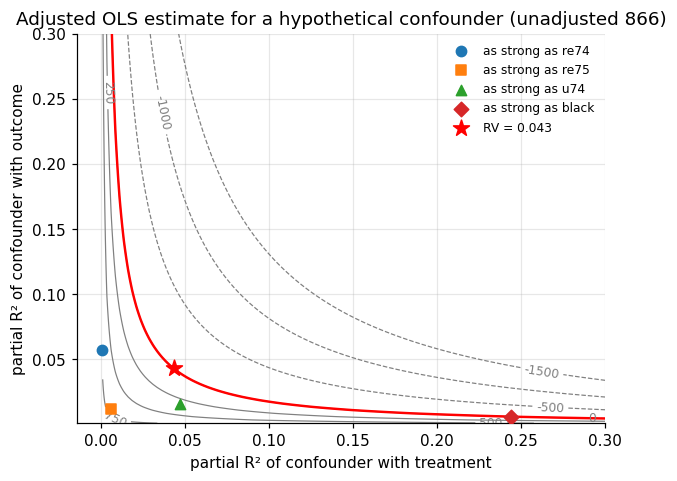

In [34]:
def adjusted_estimate(est, se, dof, r2y, r2t):
  return est - np.sign(est) * se * np.sqrt(dof) * np.sqrt(r2y * r2t / (1 - r2t))

est_p, se_p = fit_p.params["treat"], fit_p.bse["treat"]
g = np.linspace(0.001, 0.30, 120)
R2T, R2Y = np.meshgrid(g, g)
Z = adjusted_estimate(est_p, se_p, df_res, R2Y, R2T)
fig, ax = plt.subplots(figsize=(6.2, 4.6))
cs = ax.contour(R2T, R2Y, Z, levels=[-1500, -1000, -500, 0, 250, 500, 750], colors="grey", linewidths=0.8)
ax.clabel(cs, fmt="%.0f", fontsize=8)
ax.contour(R2T, R2Y, Z, levels=[0], colors="red", linewidths=1.6)
for v, mk in [("re74", "o"), ("re75", "s"), ("u74", "^"), ("black", "D")]:
  ax.scatter(bench_r2.loc[v, "R2_T~Z|X"], bench_r2.loc[v, "R2_Y~Z|T,X"], marker=mk, s=45, zorder=4, label=f"as strong as {v}")
rv = robustness_value(t_stat, df_res); ax.scatter([rv], [rv], color="red", marker="*", s=120, zorder=5, label=f"RV = {rv:.3f}")
ax.set_xlabel("partial R² of confounder with treatment"); ax.set_ylabel("partial R² of confounder with outcome")
ax.set_title(f"Adjusted OLS estimate for a hypothetical confounder (unadjusted {est_p:,.0f})"); ax.legend(frameon=False, fontsize=8)
plt.show()

The robustness value of the primary OLS estimate is about **0.04**: a confounder that explained 4% of the residual variance of *both* the treatment and 1978 earnings would erase the estimate entirely, and since the estimate is not significant at 5% to begin with, $RV_{1,0.05}=0$. That is weak robustness, but the benchmarks show how the number should be read. Race is far more strongly associated with treatment ($R^2_{T\sim \texttt{black}\mid X}\approx 0.24$) than with the outcome, and 1974 earnings the reverse ($R^2_{Y\sim \texttt{re74}\mid T,X}\approx 0.06$); a confounder that combined the treatment-association of `black` with the outcome-association of `re74` would flip the sign, whereas one as strong as `re75` on both dimensions would not. No observed covariate is simultaneously strong on both margins, which is mild comfort but not a guarantee.

### 10.2 E-values (VanderWeele and Ding, 2017)

The E-value asks the same question on the risk-ratio scale: the minimum strength of association, on the risk-ratio scale, that an unmeasured confounder would need to have with *both* treatment and outcome to fully explain away an observed association. For a risk ratio $RR\ge 1$,

$$
E = RR + \sqrt{RR\,(RR-1)},
$$

and for $RR<1$ the formula is applied to $1/RR$. For a continuous outcome the estimate is first standardized, $d = \hat\tau/\hat\sigma_Y$, and converted to an approximate risk ratio with $RR \approx \exp(0.91\,d)$ (VanderWeele and Ding's continuous-outcome approximation, based on Chinn's (2000) conversion between $d$ and log odds ratios). The same transformation applied to the confidence limit nearest the null gives the E-value for the interval, which is 1 whenever the interval already contains zero. I compute both for each estimator, using the standard deviation of `re78` in the observational sample.

In [35]:
def e_value(rr):
  rr = rr if rr >= 1 else 1 / rr
  return rr + np.sqrt(rr * (rr - 1))

def e_values(est, se, sd_y):
  lo, hi = ci(est, se)
  e_point = e_value(np.exp(0.91 * est / sd_y))
  limit = lo if est > 0 else hi
  e_ci = 1.0 if lo <= 0 <= hi else e_value(np.exp(0.91 * limit / sd_y))
  return e_point, e_ci

sd_y = observational["re78"].std(ddof=1)
ev_rows = {
  "OLS dummy": (ols_table.loc[PRIMARY, "estimate"], ols_table.loc[PRIMARY, "SE (HC1)"]),
  "g-computation": (gcomp_table.loc[PRIMARY, "estimate"], gcomp_table.loc[PRIMARY, "bootstrap SE"]),
  "IPW-ATT": (ipw_table.loc[PRIMARY, "estimate"], ipw_table.loc[PRIMARY, "bootstrap SE"]),
  "matching, M = 10": (sweep_table.loc[10, "estimate"], sweep_table.loc[10, "AI SE"]),
  "AIPW": (aipw_table.loc[PRIMARY, "estimate"], aipw_table.loc[PRIMARY, "bootstrap SE"]),
  "experimental benchmark": (BENCH, BENCH_SE),
}
ev_table = pd.DataFrame({k: dict(zip(["estimate", "SE", "E-value (point)", "E-value (CI)"], (*v, *e_values(*v, sd_y)))) for k, v in ev_rows.items()}).T
ev_table.round(2)

,estimate,SE,E-value (point),E-value (CI)
OLS dummy,865.59,738.52,1.46,1.00
g-computation,1170.27,812.67,1.57,1.00
IPW-ATT,1003.39,846.12,1.51,1.00
"matching, M = 10",1056.64,842.91,1.53,1.00
AIPW,851.80,837.28,1.46,1.00
experimental benchmark,1794.34,671.00,1.80,1.31


The E-values for the point estimates are modest (≈ 1.5–1.6) and those for the confidence intervals are all 1, because every interval includes zero. Note that even the *experimental* benchmark has an E-value of only 1.8 for its point estimate—an illustration that E-values scale with effect size, and that a program effect of one quarter of a standard deviation of earnings is a small effect in these units however clean the design. The E-value's continuous-outcome approximation is crude, and the two sensitivity tools carry different scales, but they agree on the substance: the observational estimates are not robust to a moderately strong unobserved confounder, and the honest conclusion is that the point estimates are positive but imprecise.

<a id="11"></a>
## 11. Synthesis

### 11.1 All estimators against the benchmark

In [36]:
summary = pd.DataFrame({
    "experimental benchmark (diff. in means)": (BENCH, BENCH_SE, "Neyman"),
    "naive comparison, CPS-3": (naive, np.sqrt(observational.loc[obs_t, 're78'].var(ddof=1) / obs_t.sum() + observational.loc[~obs_t, 're78'].var(ddof=1) / (~obs_t).sum()), "Neyman"),
    "OLS with treatment dummy": (ols_table.loc[PRIMARY, "estimate"], ols_table.loc[PRIMARY, "SE (HC1)"], "HC1"),
    "g-computation (ATT)": (gcomp_table.loc[PRIMARY, "estimate"], gcomp_table.loc[PRIMARY, "bootstrap SE"], "bootstrap"),
    "IPW (ATT weights)": (ipw_table.loc[PRIMARY, "estimate"], ipw_table.loc[PRIMARY, "bootstrap SE"], "bootstrap"),
    "1-NN matching, caliper": (match1_table.loc[PRIMARY, "estimate"], match1_table.loc[PRIMARY, "AI SE"], "Abadie-Imbens"),
    "10-NN matching": (sweep_table.loc[10, "estimate"], sweep_table.loc[10, "AI SE"], "Abadie-Imbens"),
    "AIPW (doubly robust)": (aipw_table.loc[PRIMARY, "estimate"], aipw_table.loc[PRIMARY, "bootstrap SE"], "bootstrap"),
    "cross-fitted AIPW, random forests": (DML_EST, DML_SE, "IF + split dispersion"),
}, index=["estimate", "SE", "SE method"]).T
summary["estimate"] = summary["estimate"].astype(float); summary["SE"] = summary["SE"].astype(float)
summary["95% CI lower"], summary["95% CI upper"] = ci(summary["estimate"], summary["SE"])
summary["gap to benchmark"] = summary["estimate"] - BENCH
summary["gap in SE units"] = summary["gap to benchmark"] / np.sqrt(summary["SE"] ** 2 + BENCH_SE ** 2)
summary["CI covers benchmark"] = (summary["95% CI lower"] <= BENCH) & (BENCH <= summary["95% CI upper"])
summary.round(2)

,estimate,SE,SE method,95% CI lower,95% CI upper,gap to benchmark,gap in SE units,CI covers benchmark
experimental benchmark (diff. in means),1794.34,671.00,Neyman,479.21,3109.47,0.00,0.00,True
"naive comparison, CPS-3",-635.03,677.20,Neyman,-1962.30,692.25,-2429.37,-2.55,False
OLS with treatment dummy,865.59,738.52,HC1,-581.88,2313.05,-928.76,-0.93,True
g-computation (ATT),1170.27,812.67,bootstrap,-422.53,2763.06,-624.07,-0.59,True
IPW (ATT weights),1003.39,846.12,bootstrap,-654.99,2661.76,-790.96,-0.73,True
"1-NN matching, caliper",-1682.46,1563.95,Abadie-Imbens,-4747.75,1382.82,-3476.80,-2.04,False
10-NN matching,1056.64,842.91,Abadie-Imbens,-595.42,2708.71,-737.70,-0.68,True
AIPW (doubly robust),851.80,837.28,bootstrap,-789.23,2492.83,-942.54,-0.88,True
"cross-fitted AIPW, random forests",995.82,741.16,IF + split dispersion,-456.82,2448.47,-798.52,-0.80,True


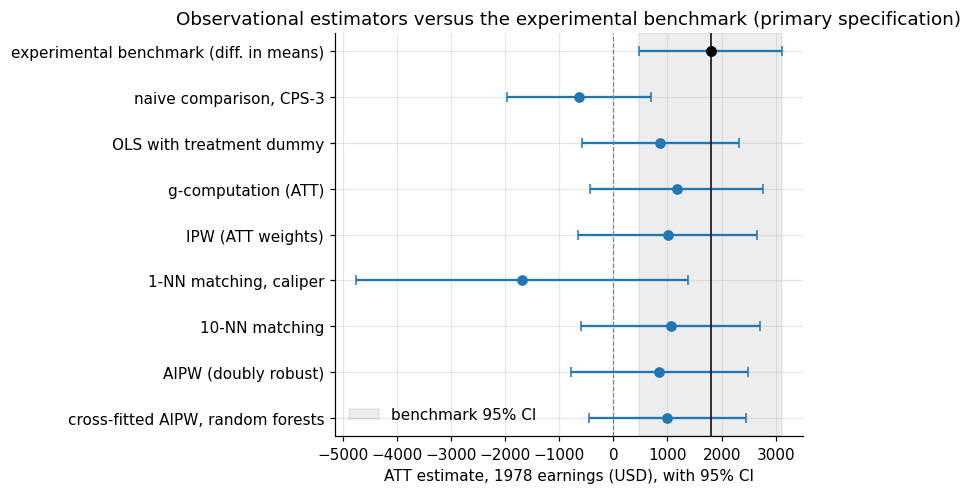

In [37]:
fig, ax = plt.subplots(figsize=(7.5, 4.6))
labels = summary.index[::-1]; est = summary["estimate"].values[::-1]; se = summary["SE"].values[::-1]
yy = np.arange(len(labels))
ax.errorbar(est, yy, xerr=1.96 * se, fmt="o", capsize=3, color="C0")
ax.scatter(est[-1], yy[-1], color="k", zorder=5)
ax.axvline(BENCH, color="k", lw=1); ax.axvspan(*ci(BENCH, BENCH_SE), color="k", alpha=0.07, label="benchmark 95% CI")
ax.axvline(0, color="grey", lw=0.8, ls="--")
ax.set_yticks(yy); ax.set_yticklabels(labels); ax.set_xlabel("ATT estimate, 1978 earnings (USD), with 95% CI")
ax.set_title("Observational estimators versus the experimental benchmark (primary specification)")
ax.legend(frameon=False, loc="lower left"); plt.tight_layout(); plt.show()

### 11.2 What the exercise establishes

1. **The estimand has to be chosen before the estimator.** With an experimental treatment group and a general-population comparison group, the only estimable and benchmarkable quantity is the ATT. Using ATE weights on the same propensity score gives \$225 (linear specification) or a negative number (primary specification)—not because weighting fails but because it answers a question about the CPS-3 population that nobody asked and that the experiment cannot check.

2. **Conditioning on observables removes most of the selection bias.** The raw CPS-3 comparison is off by *−\$2,429*. Under the primary specification every ATT estimator lands between about *\$850* and *\$1,200*, all with 95% intervals covering the benchmark of *\$1,794*, and none more than one combined standard error away from it. The residual shortfall of *\$600–\$950* is consistent with modest selection on unobservables (motivation, local labor-market conditions, the timing of the pre-program earnings dip) but is not statistically distinguishable from zero.

3. **The zero-earnings indicators are the single most important modelling choice.** They encode the program's eligibility rule. Without them the propensity score cannot balance `u74` (weighted SMD ≈ 0.5), and OLS attributes to the program part of the difference between chronically non-employed trainees and the CPS men.

4. **One-to-one matching is not a safe default in a comparison pool of this size.** It uses 60–80 of the 429 comparison men, reuses individuals up to 25 times, and swings between −\$1,700 and +\$2,150 across specifications that are otherwise interchangeable. The Abadie–Imbens variance reports this honestly (SE \$1,000–\$1,560); the naive bootstrap of the matched sample halves it. Matching with $M\approx 10$ neighbours behaves like the weighting estimators, as theory says it should.

5. **Standard errors dominate specification differences.** The benchmark's own standard error is *\$671*; the observational estimators' are *\$750–\$900.* Debates about whether *\$1,000* or *\$1,450* is the "right" observational estimate are debates within the noise, and reported precision should be believed only when the inference method matches the estimator.

6. **Robustness to unobserved confounding is limited**, as the small robustness values and E-values show—unsurprisingly, since the estimated effect is about a quarter of a standard deviation of earnings.

### 11.3 Limitations and extensions

- **Comparison group.** CPS-3 is pre-screened toward NSW eligibility. The full CPS-1 (15,992 men) and the PSID samples used by LaLonde are far harder cases, and Smith and Todd (2005) show that the success of propensity-score methods on the Dehejia–Wahba subsample does not carry over to them. Repeating this notebook on those samples is the natural next step.
- **Outcome distribution.** Earnings are skewed with a large mass at zero. Effects on employment (`re78 > 0`), on log earnings among the employed, or quantile treatment effects would give a fuller picture than the mean.
- **Longitudinal structure.** Two pre-periods are available, so difference-in-differences and its doubly robust variants (Sant'Anna and Zhao, 2020) could exploit the panel dimension rather than treating `re74`/`re75` purely as covariates—at the cost of a parallel-trends assumption that the Ashenfelter dip makes questionable.
- **Inference for matching on an estimated score** should use the Abadie–Imbens (2016) adjustment, and the population-ATT variance adds a heterogeneity term I omitted.
- **Sensitivity benchmarks** used the observed covariates' partial $R^2$ as informal reference points; Cinelli and Hazlett's formal bounds for "$k$ times as strong as covariate $j$" are slightly different quantities.

<a id="12"></a>
## 12. References

- Abadie, A., and Imbens, G. W. (2006). Large sample properties of matching estimators for average treatment effects. *Econometrica*, 74(1), 235–267.
- Abadie, A., and Imbens, G. W. (2008). On the failure of the bootstrap for matching estimators. *Econometrica*, 76(6), 1537–1557.
- Abadie, A., and Imbens, G. W. (2011). Bias-corrected matching estimators for average treatment effects. *Journal of Business & Economic Statistics*, 29(1), 1–11.
- Abadie, A., and Imbens, G. W. (2016). Matching on the estimated propensity score. *Econometrica*, 84(2), 781–807.
- Angrist, J. D. (1998). Estimating the labor market impact of voluntary military service using Social Security data on military applicants. *Econometrica*, 66(2), 249–288.
- Austin, P. C. (2009). Balance diagnostics for comparing the distribution of baseline covariates between treatment groups in propensity-score matched samples. *Statistics in Medicine*, 28(25), 3083–3107.
- Austin, P. C. (2011). Optimal caliper widths for propensity-score matching when estimating differences in means and differences in proportions in observational studies. *Pharmaceutical Statistics*, 10(2), 150–161.
- Bang, H., and Robins, J. M. (2005). Doubly robust estimation in missing data and causal inference models. *Biometrics*, 61(4), 962–973.
- Chernozhukov, V., Chetverikov, D., Demirer, M., Duflo, E., Hansen, C., Newey, W., and Robins, J. (2018). Double/debiased machine learning for treatment and structural parameters. *The Econometrics Journal*, 21(1), C1–C68.
- Chinn, S. (2000). A simple method for converting an odds ratio to effect size for use in meta-analysis. *Statistics in Medicine*, 19(22), 3127–3131.
- Cinelli, C., and Hazlett, C. (2020). Making sense of sensitivity: extending omitted variable bias. *Journal of the Royal Statistical Society: Series B*, 82(1), 39–67.
- Dehejia, R. H., and Wahba, S. (1999). Causal effects in nonexperimental studies: reevaluating the evaluation of training programs. *Journal of the American Statistical Association*, 94(448), 1053–1062.
- Dehejia, R. H., and Wahba, S. (2002). Propensity score-matching methods for nonexperimental causal studies. *Review of Economics and Statistics*, 84(1), 151–161.
- Heckman, J. J., Ichimura, H., and Todd, P. E. (1997). Matching as an econometric evaluation estimator: evidence from evaluating a job training programme. *Review of Economic Studies*, 64(4), 605–654.
- Hirano, K., Imbens, G. W., and Ridder, G. (2003). Efficient estimation of average treatment effects using the estimated propensity score. *Econometrica*, 71(4), 1161–1189.
- Imbens, G. W. (2015). Matching methods in practice: three examples. *Journal of Human Resources*, 50(2), 373–419.
- Imbens, G. W., and Rubin, D. B. (2015). *Causal Inference for Statistics, Social, and Biomedical Sciences: An Introduction*. Cambridge University Press.
- LaLonde, R. J. (1986). Evaluating the econometric evaluations of training programs with experimental data. *American Economic Review*, 76(4), 604–620.
- Lin, W. (2013). Agnostic notes on regression adjustments to experimental data: reexamining Freedman's critique. *Annals of Applied Statistics*, 7(1), 295–318.
- Robins, J. M., Rotnitzky, A., and Zhao, L. P. (1994). Estimation of regression coefficients when some regressors are not always observed. *Journal of the American Statistical Association*, 89(427), 846–866.
- Rosenbaum, P. R., and Rubin, D. B. (1983). The central role of the propensity score in observational studies for causal effects. *Biometrika*, 70(1), 41–55.
- Sant'Anna, P. H. C., and Zhao, J. (2020). Doubly robust difference-in-differences estimators. *Journal of Econometrics*, 219(1), 101–122.
- Słoczyński, T. (2022). Interpreting OLS estimands when treatment effects are heterogeneous: smaller groups get larger weights. *Review of Economics and Statistics*, 104(3), 501–509.
- Smith, J. A., and Todd, P. E. (2005). Does matching overcome LaLonde's critique of nonexperimental estimators? *Journal of Econometrics*, 125(1–2), 305–353.
- VanderWeele, T. J., and Ding, P. (2017). Sensitivity analysis in observational research: introducing the E-value. *Annals of Internal Medicine*, 167(4), 268–274.

**Data.** NSW/Dehejia–Wahba experimental sample and CPS-3 comparison sample, distributed by Rajeev Dehejia (`nswre74_treated.txt`, `nswre74_control.txt`, `cps3_controls.txt`).